In [1]:
# Install required packages
# Run this cell once before executing the rest of the notebook.
%pip install numpy pandas scikit-learn matplotlib seaborn torch torchvision Pillow joblib tqdm python-dotenv google-auth google-auth-oauthlib google-api-python-client scikit-image scipy



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Heat Treatment Parameter Prediction — `database-debug` worksheet (low-res morph)

Variant of `microstructure_debug.ipynb`. Uses the same `metadata_debug.csv`
data source and pinned `dinov2_vitb14` backbone, but adds an explicit image
**resolution-standardization** step before extracting morphological features.

**Why this notebook exists**
Morphological feature extraction (grain area, aspect ratio, GLCM texture,
LBP, etc.) is sensitive to the input resolution: a 3840×2400 micrograph and
a 1198×1920 micrograph give visibly different grain statistics even when the
underlying microstructure is identical. The full `metadata_debug` image set,
restricted to the five DP grades we care about, contains 5,054 images at
8 distinct (W, H) sizes. The smallest short-side is **1198 px** (the
`25_4_15kv_bsd_full_130µm_4000x_*` set). This notebook downsamples every
image to a **short-side of 1198 px, preserving aspect ratio** (LANCZOS
filter) before any feature extraction, so morph features are computed at a
consistent spatial scale.

**Alloys included** (defensively filtered, even though `metadata_debug.csv`
is already restricted to these five):
- DP1180 GA, DP590 GA, DP600 GI, DP780 GA, DP980 GA

**Caches are isolated** under `data/private_only_debug_lowres/` and
`features/private_only_debug_lowres/` so the existing
`private_only_debug` caches (full-res) stay intact for side-by-side
comparison. RunStore scope = `debug_lowres`, so artefacts go to
`runs/debug_lowres/`.

**Targets**: Cycle 1 HoldingTemp + HoldingTime
**Approach**: Multi-output ensemble regression (GBR vs XGB)

**Sections**:
1. **Data Loading & Exploration**
2. **Target Extraction**
3. **Tabular Feature Preprocessing**
3b. **Standardize image resolution + Morphological Feature Extraction**
4. **Image Feature Extraction** (dinov2_vitb14, recomputed on the lowres set)
5. **Model Training & Evaluation**
6. **Visualization** (incl. §6c outlier IDs)
7. **Log Run Metrics**

In [2]:
# Standard imports
import os
import re
import sys
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path for local imports
sys.path.insert(0, os.path.abspath('..'))

# Project imports
from src import hyperparams as hp
from src.config import Config, PreprocessingConfig, MissingDataConfig, ScalingConfig, EncodingConfig
from src.preprocessing import FeaturePreprocessor
from src.extraction import FeatureExtractor, BackboneRegistry, MorphologicalExtractor, MorphologyConfig
from src.extraction.extractor import ExtractionConfig
from src.model_trainer import (
    ModelTrainer,
    build_ensemble_models,
    evaluate_model,
    plot_predictions,
    plot_learning_curves,
    plot_model_comparison
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display settings
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

from src.features import FeaturePipeline

from src.run_store import RunStore
from src import metrics_viz


## 1. Data Loading & Exploration

The `metadata_debug.csv` dataset is the export of the `database-debug` worksheet and contains alloy samples with:
- **Chemical Composition**: C, Mn, Si, Cr, P, S, Mo, Cu, Ni, Al, Nb, V, Ti, Fe
- **Heat Treatment Parameters**: Up to 4 cycles, each with HoldingTemp, HoldingTime, CRate
- **Metadata**: Alloy names, sample IDs, image references

The CSV has a category header row, so we load with `header=1` and filter out empty padding rows.

In [3]:
# ── RunStore: allocate this run's output directory ──────────────────────────
_store = RunStore("debug_lowres")
_run_dir, _run_id = _store.start()
print(f"Run directory: {_run_dir}")

# Load the metadata dataset
from src.column_sanitizer import sanitize_dataframe, sanitize_column

df_raw = pd.read_csv("../datasets/metadata_debug.csv", header=1)
print(f"Raw dataset shape: {df_raw.shape}")

# Sanitize all column names to [a-z0-9_] immediately after loading.
# All downstream code uses sanitized names exclusively.
df_raw = sanitize_dataframe(df_raw)

# Filter to rows with actual data (non-null chemical composition)
df = df_raw[df_raw["c"].notna()].copy().reset_index(drop=True)
print(f"Usable samples: {df.shape[0]} (filtered from {len(df_raw)} raw rows)")
print(f"Columns: {len(df.columns)}")
df.head()


Run directory: /Users/ayobamibamigboye/capstone/model/runs/debug_lowres/20260504_100001_f151
Raw dataset shape: (444, 69)
Usable samples: 444 (filtered from 444 raw rows)
Columns: 69


,alloy,article_url,id,original_image,ai_cleaned_image,augumented_data,c,mn,si,cr,p,s,mo,cu,ni,al,nb,v,ti,ti_nb_v,b,ce_la,fe,pixel_size,heat_treatment_type,...,cycle2_rtemp_degc,cycle2_rpercentage,cycle2_qtype,cycle2_qtemp_degc,cycle2_qtime_min,cycle3_hrate_degc_min,cycle3_holdingtemp_degc,cycle3_holdingtime_min,cycle3_crate_degc_s,cycle3_rolling,cycle3_rtemp,cycle3_rpercentage,cycle3_qtype,cycle3_qtemp,cycle3_qtime,cycle4_hrate_degc_min,cycle4_holdingtemp_degc,cycle4_holdingtime_min,cycle4_crate_degc_s,cycle4_rolling,cycle4_rtemp,cycle4_rpercentage,cycle4_qtype,cycle4_qtemp,cycle4_qtime
0,DP600 GI,NaN,10_9_sample_image_04_28_17_34_5,NaN,NaN,https://drive.google.com/drive/folders/1DLBbpa...,0.106,1.49,0.19,0.16,0.008,0.002,NaN,NaN,NaN,0.033,NaN,NaN,NaN,NaN,NaN,NaN,98.011,NaN,Austenizing → water quenching → tempering → w...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DP600 GI,NaN,10_9_sample_image_04_28_17_33_4,NaN,NaN,https://drive.google.com/drive/folders/1hrzYda...,0.106,1.49,0.19,0.16,0.008,0.002,NaN,NaN,NaN,0.033,NaN,NaN,NaN,NaN,NaN,NaN,98.011,NaN,Austenizing → water quenching → tempering → w...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DP600 GI,NaN,10_9_sample_image_04_28_17_31_3,NaN,NaN,https://drive.google.com/drive/folders/1zDXX1v...,0.106,1.49,0.19,0.16,0.008,0.002,NaN,NaN,NaN,0.033,NaN,NaN,NaN,NaN,NaN,NaN,98.011,NaN,Austenizing → water quenching → tempering → w...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DP600 GI,NaN,10_9_sample_image_04_28_17_30_2,NaN,NaN,https://drive.google.com/drive/folders/1boNwNG...,0.106,1.49,0.19,0.16,0.008,0.002,NaN,NaN,NaN,0.033,NaN,NaN,NaN,NaN,NaN,NaN,98.011,NaN,Austenizing → water quenching → tempering → w...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DP600 GI,NaN,10_9_sample_image_04_28_17_29_1,NaN,NaN,https://drive.google.com/drive/folders/1xgy9wK...,0.106,1.49,0.19,0.16,0.008,0.002,NaN,NaN,NaN,0.033,NaN,NaN,NaN,NaN,NaN,NaN,98.011,NaN,Austenizing → water quenching → tempering → w...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display all column names
print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

for i, col in enumerate(df.columns):
    print(f"{i:3d}. {col}")

# Identify target-related columns and their availability
print("\n" + "=" * 60)
print("TARGET COLUMN AVAILABILITY (HoldingTemp, HoldingTime, CRate)")
print("=" * 60)

for col in df.columns:
    if any(kw in col for kw in ['holdingtemp', 'holdingtime', 'crate']):
        nn = df[col].notna().sum()
        print(f"  {repr(col):55s}  {nn:3d}/{len(df)} ({nn/len(df)*100:.0f}%)")

DATASET COLUMNS
  0. alloy
  1. article_url
  2. id
  3. original_image
  4. ai_cleaned_image
  5. augumented_data
  6. c
  7. mn
  8. si
  9. cr
 10. p
 11. s
 12. mo
 13. cu
 14. ni
 15. al
 16. nb
 17. v
 18. ti
 19. ti_nb_v
 20. b
 21. ce_la
 22. fe
 23. pixel_size
 24. heat_treatment_type
 25. num_cycles
 26. cycle0_rolling
 27. cycle0_rtemp
 28. cycle0_rpercentage
 29. cycle1_hrate_degc_min
 30. cycle1_holdingtemp_degc
 31. cycle1_holdingtime_min
 32. cycle1_crate_degc_s
 33. cycle1_rolling
 34. cycle1_rtemp
 35. cycle1_rpercentage
 36. cycle1_qtype
 37. cycle1_qtemp
 38. cycle1_qtime_min
 39. cycle2_hrate_degc_min
 40. cycle2_holdingtemp_degc
 41. cycle2_holdingtime_min
 42. cycle2_crate_degc_s
 43. cycle2_rolling
 44. cycle2_rtemp_degc
 45. cycle2_rpercentage
 46. cycle2_qtype
 47. cycle2_qtemp_degc
 48. cycle2_qtime_min
 49. cycle3_hrate_degc_min
 50. cycle3_holdingtemp_degc
 51. cycle3_holdingtime_min
 52. cycle3_crate_degc_s
 53. cycle3_rolling
 54. cycle3_rtemp
 55. cycle3_

In [5]:
# Examine data types and missing values
print("Data Types and Missing Values:")
print("-" * 60)

info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1)
})

# Show columns with significant data
info_df[info_df['non_null'] > 0].head(30)

Data Types and Missing Values:
------------------------------------------------------------


,dtype,non_null,null_count,null_pct
alloy,object,444,0,0.0
id,object,444,0,0.0
augumented_data,object,444,0,0.0
c,float64,444,0,0.0
mn,float64,444,0,0.0
si,float64,444,0,0.0
cr,float64,444,0,0.0
p,float64,444,0,0.0
s,float64,444,0,0.0
al,float64,444,0,0.0


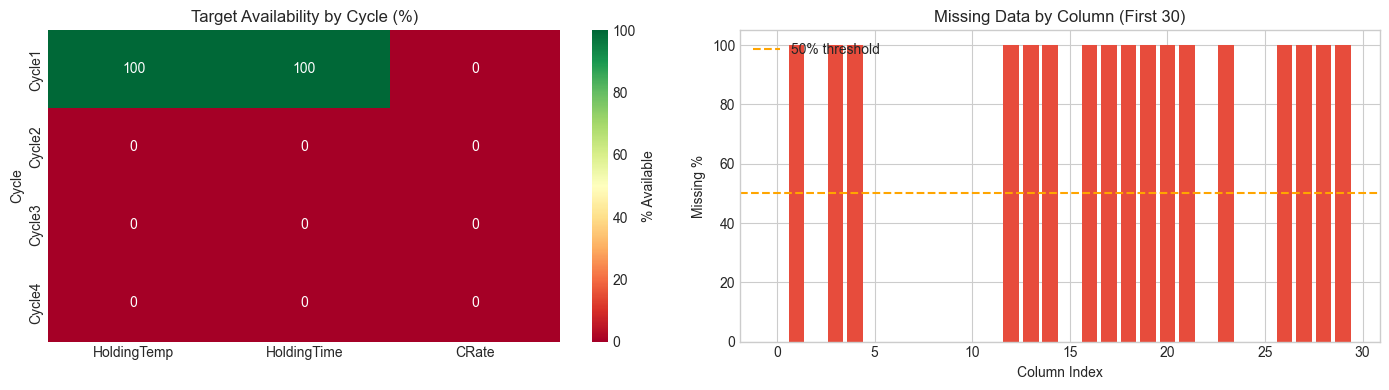


Conclusion (computed from data):
  - Cycle 1 HoldingTemp & HoldingTime: 100% / 100% available -> PRIMARY TARGETS
  - Cycle 2 HoldingTemp & HoldingTime: 0% / 0% available -> EXTENSION TARGETS
  - CRate: 0% max available across all cycles -> EXCLUDED
  - Cycles 3-4: 0% max available -> EXCLUDED

Note: target columns are NOT imputed — these percentages reflect
      actual label availability. Missing targets = excluded samples.


In [6]:
# Target availability heatmap by cycle
# Column names are sanitized: e.g. cycle1_holdingtemp_degc, cycle1_holdingtime_min, cycle1_crate_degc_s
target_params = ['holdingtemp', 'holdingtime', 'crate']
target_labels = ['HoldingTemp', 'HoldingTime', 'CRate']
cycles = ['cycle1', 'cycle2', 'cycle3', 'cycle4']
cycle_labels = ['Cycle1', 'Cycle2', 'Cycle3', 'Cycle4']

availability = pd.DataFrame(index=cycle_labels, columns=target_labels, dtype=float)

for col in df.columns:
    for cycle, clabel in zip(cycles, cycle_labels):
        for param, plabel in zip(target_params, target_labels):
            if col.startswith(cycle + '_') and param in col:
                availability.loc[clabel, plabel] = df[col].notna().sum() / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(availability.astype(float), annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=axes[0], cbar_kws={'label': '% Available'})
axes[0].set_title('Target Availability by Cycle (%)')
axes[0].set_ylabel('Cycle')

# Missing data bar chart for first 30 columns
missing_pct = (df.iloc[:, :30].isna().sum() / len(df) * 100)
colors = ['#2ecc71' if x < 50 else '#e74c3c' for x in missing_pct]
axes[1].bar(range(len(missing_pct)), missing_pct, color=colors)
axes[1].set_xlabel('Column Index')
axes[1].set_ylabel('Missing %')
axes[1].set_title('Missing Data by Column (First 30)')
axes[1].axhline(y=50, color='orange', linestyle='--', label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute conclusions dynamically from actual data
c1_temp_pct = availability.loc['Cycle1', 'HoldingTemp']
c1_time_pct = availability.loc['Cycle1', 'HoldingTime']
c2_temp_pct = availability.loc['Cycle2', 'HoldingTemp']
c2_time_pct = availability.loc['Cycle2', 'HoldingTime']
crate_max   = availability['CRate'].max()
c34_max     = availability.loc[['Cycle3', 'Cycle4'], ['HoldingTemp', 'HoldingTime']].max().max()

print("\nConclusion (computed from data):")
print(f"  - Cycle 1 HoldingTemp & HoldingTime: {c1_temp_pct:.0f}% / {c1_time_pct:.0f}% available -> PRIMARY TARGETS")
print(f"  - Cycle 2 HoldingTemp & HoldingTime: {c2_temp_pct:.0f}% / {c2_time_pct:.0f}% available -> EXTENSION TARGETS")
print(f"  - CRate: {crate_max:.0f}% max available across all cycles -> EXCLUDED")
print(f"  - Cycles 3-4: {c34_max:.0f}% max available -> EXCLUDED")
print()
print("Note: target columns are NOT imputed — these percentages reflect")
print("      actual label availability. Missing targets = excluded samples.")

Alloy Types in Dataset:
----------------------------------------
alloy
DP590 GA     93
DP600 GI     90
DP980 GA     89
DP1180 GA    88
DP780 GA     84
Name: count, dtype: int64


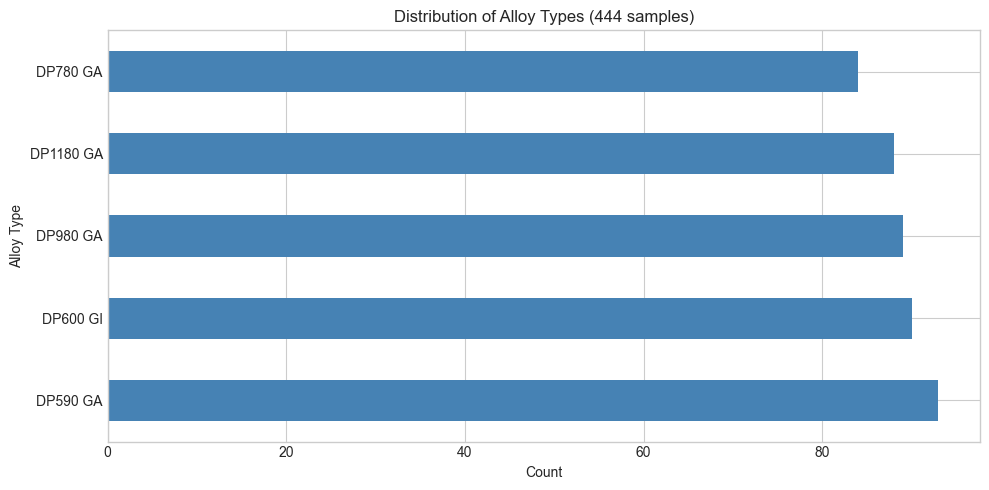

In [7]:
# Examine unique alloy types
print("Alloy Types in Dataset:")
print("-" * 40)
alloy_counts = df['alloy'].value_counts()
print(alloy_counts)

# Visualize alloy distribution
fig, ax = plt.subplots(figsize=(10, 5))
alloy_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_ylabel('Alloy Type')
ax.set_title(f'Distribution of Alloy Types ({len(df)} samples)')
plt.tight_layout()
plt.show()

## 2. Target Extraction

**Primary targets**: Cycle 1 HoldingTemp (C) and HoldingTime (min) — 82/88 samples available

**Strategy**:
- CRate excluded due to extreme sparsity (9% for Cycle 1, 0% for Cycles 2-4)
- Cycles 3-4 excluded (<20% availability)
- Samples missing Cycle 1 targets are dropped from training
- All heat treatment columns excluded from input features to prevent target leakage

In [8]:
# Target columns — use sanitized names directly (no fuzzy matching needed)
# since column names are normalized at load time.
def find_column(df, sanitized_name):
    """Return sanitized_name if present in df.columns, else None."""
    return sanitized_name if sanitized_name in df.columns else None

TARGET_PATTERNS = {
    "Cycle1_HoldingTemp": "cycle1_holdingtemp_degc",
    "Cycle1_HoldingTime": "cycle1_holdingtime_min",
    "Cycle2_HoldingTemp": "cycle2_holdingtemp_degc",
    "Cycle2_HoldingTime": "cycle2_holdingtime_min",
}

target_col_map = {}
print("Target column mapping:")
for key, col in TARGET_PATTERNS.items():
    actual = find_column(df, col)
    if actual:
        target_col_map[key] = actual
        nn = df[actual].notna().sum()
        print(f"  {key:<25} -> {repr(actual)}  ({nn}/{len(df)} available)")
    else:
        print(f"  {key:<25} -> NOT FOUND")


Target column mapping:
  Cycle1_HoldingTemp        -> 'cycle1_holdingtemp_degc'  (444/444 available)
  Cycle1_HoldingTime        -> 'cycle1_holdingtime_min'  (444/444 available)
  Cycle2_HoldingTemp        -> 'cycle2_holdingtemp_degc'  (0/444 available)
  Cycle2_HoldingTime        -> 'cycle2_holdingtime_min'  (0/444 available)


In [9]:
# ── Defensive alloy filter ──────────────────────────────────────────────────
# metadata_debug.csv is already restricted to these five DP grades, but this
# filter makes the restriction explicit so future CSV edits can't silently
# pull in non-DP rows. Match is case-insensitive and strip-trimmed; raises
# loudly if zero rows survive (the only way that happens is a bad CSV).
ALLOWED_ALLOYS = {"dp1180 ga", "dp590 ga", "dp600 gi", "dp780 ga", "dp980 ga"}
_alloy_norm = df["alloy"].astype(str).str.strip().str.lower()
_alloy_mask = _alloy_norm.isin(ALLOWED_ALLOYS)
print(f"Alloy filter: keeping {_alloy_mask.sum()}/{len(df)} rows  "
      f"({sorted(_alloy_norm[_alloy_mask].unique())})")
if not _alloy_mask.any():
    raise RuntimeError(
        f"No rows match ALLOWED_ALLOYS={ALLOWED_ALLOYS}. "
        f"Alloys actually present: {sorted(_alloy_norm.unique())[:20]}"
    )
df = df[_alloy_mask].copy().reset_index(drop=True)

# Build Cycle 1 working subset
c1_temp_col = target_col_map["Cycle1_HoldingTemp"]
c1_time_col = target_col_map["Cycle1_HoldingTime"]

c1_mask = df[c1_temp_col].notna() & df[c1_time_col].notna()
df_c1 = df[c1_mask].copy().reset_index(drop=True)

target_columns = [c1_temp_col, c1_time_col]
Y_c1 = df_c1[target_columns].values.astype(np.float64)

print(f"Cycle 1 subset: {len(df_c1)} samples")
print(f"Target columns: {target_columns}")
for i, col in enumerate(target_columns):
    vals = Y_c1[:, i]
    print(f"  {col}: range=[{vals.min():.1f}, {vals.max():.1f}], mean={vals.mean():.1f}, std={vals.std():.1f}")


Alloy filter: keeping 444/444 rows  (['dp1180 ga', 'dp590 ga', 'dp600 gi', 'dp780 ga', 'dp980 ga'])
Cycle 1 subset: 444 samples
Target columns: ['cycle1_holdingtemp_degc', 'cycle1_holdingtime_min']
  cycle1_holdingtemp_degc: range=[740.0, 860.0], mean=793.9, std=41.9
  cycle1_holdingtime_min: range=[10.0, 30.0], mean=19.5, std=8.5


## 3. Tabular Feature Preprocessing

Input features are **chemical composition only** — all heat treatment parameters are excluded to prevent target leakage. In `metadata_debug.csv`, all chemical columns are `float64` (no text-in-numeric issues).

In [10]:
# Input features: all columns EXCEPT HoldingTemp/HoldingTime across all cycles.
# Using sanitized column names throughout.
TARGET_COLUMNS_TO_EXCLUDE = [
    "cycle1_holdingtemp_degc", "cycle1_holdingtime_min",
    "cycle2_holdingtemp_degc", "cycle2_holdingtime_min",
    "cycle3_holdingtemp_degc", "cycle3_holdingtime_min",
    "cycle4_holdingtemp_degc", "cycle4_holdingtime_min",
]

feature_columns = [
    c for c in df_c1.columns
    if c not in TARGET_COLUMNS_TO_EXCLUDE
]

print(f"Selected {len(feature_columns)} input features (all columns minus HoldingTemp/HoldingTime):")
for col in feature_columns:
    nn = df_c1[col].notna().sum()
    print(f"  - {col:35s}  {nn:3d}/{len(df_c1)} ({nn/len(df_c1)*100:.0f}%) non-null  dtype={str(df_c1[col].dtype):10s}")


Selected 61 input features (all columns minus HoldingTemp/HoldingTime):
  - alloy                                444/444 (100%) non-null  dtype=object    
  - article_url                            0/444 (0%) non-null  dtype=float64   
  - id                                   444/444 (100%) non-null  dtype=object    
  - original_image                         0/444 (0%) non-null  dtype=float64   
  - ai_cleaned_image                       0/444 (0%) non-null  dtype=float64   
  - augumented_data                      444/444 (100%) non-null  dtype=object    
  - c                                    444/444 (100%) non-null  dtype=float64   
  - mn                                   444/444 (100%) non-null  dtype=float64   
  - si                                   444/444 (100%) non-null  dtype=float64   
  - cr                                   444/444 (100%) non-null  dtype=float64   
  - p                                    444/444 (100%) non-null  dtype=float64   
  - s                

In [11]:
# Create preprocessing configuration
preproc_config = PreprocessingConfig(
    missing_data=MissingDataConfig(
        column_drop_threshold=0.95,
        row_fill_threshold=0.50,
        numeric_fill_strategy="median",
        categorical_fill_strategy="mode",
        mice_max_iter=10,
    ),
    scaling=ScalingConfig(method="standard", enabled=True),
    encoding=EncodingConfig(categorical="onehot", max_categories=50),
)

MICE_COLUMNS      = ["cr", "mo", "s", "p", "ni", "al"]  # p: 52% missing, benefits from MICE
INDICATOR_COLUMNS = ["ti", "nb", "v"]

print("Preprocessing Configuration:")
print(f"  Column drop threshold: {preproc_config.missing_data.column_drop_threshold}")
print(f"  Row fill threshold:    {preproc_config.missing_data.row_fill_threshold}")
print(f"  Numeric fill strategy: {preproc_config.missing_data.numeric_fill_strategy}")
print(f"  Scaling method:        {preproc_config.scaling.method}")
print(f"  MICE columns:          {MICE_COLUMNS}")
print(f"  Indicator columns:     {INDICATOR_COLUMNS}")
print(f"  Note: cu (90.6% missing) uses median — too sparse for MICE")
print(f"  Indicator columns:     {INDICATOR_COLUMNS}")

Preprocessing Configuration:
  Column drop threshold: 0.95
  Row fill threshold:    0.5
  Numeric fill strategy: median
  Scaling method:        standard
  MICE columns:          ['cr', 'mo', 's', 'p', 'ni', 'al']
  Indicator columns:     ['ti', 'nb', 'v']
  Note: cu (90.6% missing) uses median — too sparse for MICE
  Indicator columns:     ['ti', 'nb', 'v']


In [12]:
# Explicit column type overrides for columns whose pandas dtype is ambiguous.
COLUMN_TYPE_OVERRIDES = {
    "num_cycles":             "categorical",
    "cycle1_crate_degc_s":    "categorical",
    "cycle1_rtemp":           "categorical",
    "cycle1_qtemp":           "categorical",
    "cycle2_rtemp_degc":      "categorical",
    "cycle3_rtemp":           "categorical",
    "cycle3_qtemp":           "categorical",
    "cycle4_qtemp":           "categorical",
    "heat_treatment_type":    "categorical",
    "id":                     "unique_string",
}

# Split BEFORE fitting the preprocessor to avoid imputer/MICE leakage.
from sklearn.model_selection import train_test_split

idx = np.arange(len(df_c1))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val   = train_test_split(idx_trainval, test_size=0.15, random_state=42)

df_train_c1 = df_c1.iloc[idx_train].reset_index(drop=True)
df_val_c1   = df_c1.iloc[idx_val].reset_index(drop=True)
df_test_c1  = df_c1.iloc[idx_test].reset_index(drop=True)
Y_train = Y_c1[idx_train]
Y_val   = Y_c1[idx_val]
Y_test  = Y_c1[idx_test]

print(f"Split: train={len(df_train_c1)}, val={len(df_val_c1)}, test={len(df_test_c1)}")

active_overrides   = {k: v for k, v in COLUMN_TYPE_OVERRIDES.items() if k in feature_columns}
# IterativeImputer silently drops fully-empty columns and breaks the writeback
# in MICEImputer.transform_df, and indicator columns that are fully empty in
# train collapse to a constant. Filter both lists by training-split availability
# so the fit matches what's actually observable.
mice_cols      = [c for c in MICE_COLUMNS
                  if c in feature_columns and df_train_c1[c].notna().any()]
indicator_cols = [c for c in INDICATOR_COLUMNS
                  if c in feature_columns and df_train_c1[c].notna().any()]
_dropped_mice = [c for c in MICE_COLUMNS      if c in feature_columns and c not in mice_cols]
_dropped_ind  = [c for c in INDICATOR_COLUMNS if c in feature_columns and c not in indicator_cols]
if _dropped_mice or _dropped_ind:
    print(f"  MICE columns skipped (no train values): {_dropped_mice}")
    print(f"  Indicator columns skipped (no train values): {_dropped_ind}")

preprocessor = FeaturePreprocessor(
    preproc_config,
    column_types=active_overrides,
    mice_columns=mice_cols,
    indicator_columns=indicator_cols,
)

print("Fitting preprocessor on training split...")
print("=" * 60)
X_tab_train = preprocessor.fit_transform(df_train_c1[feature_columns].copy())
X_tab_val   = preprocessor.transform(df_val_c1[feature_columns].copy())
X_tab_test  = preprocessor.transform(df_test_c1[feature_columns].copy())

print()
print(f"Tabular feature shape (train): {X_tab_train.shape}")
print(f"Feature names ({len(preprocessor.get_feature_names())}):")
for name in preprocessor.get_feature_names():
    print(f"  - {name}")
if preprocessor.get_dropped_columns():
    print()
    print(f"Dropped columns: {preprocessor.get_dropped_columns()}")


Split: train=320, val=57, test=67
  MICE columns skipped (no train values): ['mo', 'ni']
  Indicator columns skipped (no train values): ['ti', 'nb', 'v']
Fitting preprocessor on training split...
  MICE fitted on ['cr', 's', 'p', 'al']
  alloy: object → categorical
  Dropping column 'article_url': 100.0% missing (threshold: 95%)
  id: object → unique_string (override)
  Dropping column 'original_image': 100.0% missing (threshold: 95%)
  Dropping column 'ai_cleaned_image': 100.0% missing (threshold: 95%)
  augumented_data: object → text
  c: float64 → numeric
  mn: float64 → numeric
  si: float64 → numeric
  cr: float64 → numeric
  p: float64 → numeric
  s: float64 → numeric
  Dropping column 'mo': 100.0% missing (threshold: 95%)
  Dropping column 'cu': 100.0% missing (threshold: 95%)
  Dropping column 'ni': 100.0% missing (threshold: 95%)
  al: float64 → numeric
  Dropping column 'nb': 100.0% missing (threshold: 95%)
  Dropping column 'v': 100.0% missing (threshold: 95%)
  Dropping col

## 3b. Morphological Feature Extraction

Before CNN feature extraction the AI-cleaned images are analysed with classical
image processing to produce **33 physically interpretable features** per image:

| Group | Features |
|-------|----------|
| Phase fractions | martensite_fraction, ferrite_fraction, phase_entropy |
| Ferrite geometry | grain_count, area mean/std/cv/skew/kurt, aspect_ratio, solidity, equiv_diam |
| Ferrite spatial | nearest-neighbour distance mean + std |
| Martensite topology | island_count, area_mean, aspect_ratio, connectivity, spacing |
| Boundary network | density, mean_width, banding_index |
| GLCM texture | contrast, energy, homogeneity, correlation, dissimilarity |
| LBP texture | entropy, uniformity |
| Intensity | local_contrast mean/std, intensity mean/std |

Images are loaded from the  column (AI-cleaned, annotation-free).
Failed images return NaN, which the preprocessor imputes with column medians.

See  for full design rationale and
literature references.


In [13]:
# ── Initialise FeaturePipeline (lowres-isolated paths) ───────────────────────
# This notebook standardizes every image to short-side 1198 px BEFORE any
# feature extraction. To keep the existing private_only_debug caches intact
# for side-by-side comparison, we use a separate cache namespace
# `private_only_debug_lowres/` for both the CNN and morph caches.
#
# Layout:
#   data/private_only_debug_lowres/temp_images/   <- downsampled images
#   data/private_only_debug_lowres/image_cache_*  <- CNN cache (lowres)
#   features/private_only_debug_lowres/morph_features_c1.npz  <- morph cache (lowres)
#
# The original full-res images in data/temp_images are never modified.
DATA_DIR     = os.path.abspath('../data/private_only_debug_lowres')
TEMP_DIR_SRC = os.path.abspath('../data/temp_images')                         # full-res source (read-only)
TEMP_DIR     = os.path.abspath('../data/private_only_debug_lowres/temp_images')  # downsampled target
FEATURES_DIR = os.path.abspath('../features/private_only_debug_lowres')

os.makedirs(TEMP_DIR, exist_ok=True)

# ── Resolution-standardization step ──────────────────────────────────────────
# For every full-res image whose row id matches the (alloy-filtered) df, write
# a downsampled copy to TEMP_DIR. Aspect ratio is preserved; the short side is
# clamped to TARGET_SHORT_SIDE. LANCZOS gives the cleanest downscale for
# subsequent morphological analysis. Images already smaller than the target
# are copied through unchanged so we don't *upscale* tiny inputs.
import shutil
import re as _re_low
from PIL import Image

TARGET_SHORT_SIDE = 1198  # smallest short-side in the 5-alloy image set
RESAMPLE_FILTER   = Image.LANCZOS
EXTS              = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
_F_RE_LOW         = _re_low.compile(r'_F_\d+\.[a-z]+$', _re_low.IGNORECASE)

def _norm_id(s):
    return _re_low.sub(r'[-\s]+', '_', str(s).strip().lower())

# Allowed row-id keys come from df, which has already been alloy-filtered in
# cell 11. Only resize images whose id maps into this set.
_allowed_ids = set(df['id'].astype(str).map(_norm_id))

_src_paths = sorted(os.path.join(TEMP_DIR_SRC, f)
                    for f in os.listdir(TEMP_DIR_SRC)
                    if os.path.splitext(f)[1].lower() in EXTS)
_to_process = []
for p in _src_paths:
    rid = _norm_id(_F_RE_LOW.sub('', os.path.basename(p)))
    if rid in _allowed_ids:
        _to_process.append(p)

print(f"Standardizing resolution: short side -> {TARGET_SHORT_SIDE} px (LANCZOS)")
print(f"  source images (alloy-filtered): {len(_to_process)} / {len(_src_paths)} on disk")

_resized = _copied = _skipped_existing = 0
for p in _to_process:
    dst = os.path.join(TEMP_DIR, os.path.basename(p))
    if os.path.exists(dst):
        _skipped_existing += 1
        continue
    with Image.open(p) as im:
        w, h = im.size
        short = min(w, h)
        if short <= TARGET_SHORT_SIDE:
            # Already at or below target — copy bytes verbatim (no upscaling).
            shutil.copy2(p, dst)
            _copied += 1
        else:
            scale = TARGET_SHORT_SIDE / float(short)
            new_w, new_h = int(round(w * scale)), int(round(h * scale))
            im_rgb = im.convert('RGB') if im.mode not in ('RGB', 'L') else im
            im_rs  = im_rgb.resize((new_w, new_h), RESAMPLE_FILTER)
            im_rs.save(dst, quality=95)
            _resized += 1
print(f"  resized: {_resized}  copied (already <= target): {_copied}  "
      f"skipped (already in lowres dir): {_skipped_existing}")

# ── Pipeline points at the lowres temp_dir ──────────────────────────────────
fp = FeaturePipeline(
    data_dir=DATA_DIR,
    temp_dir=TEMP_DIR,
    features_dir=FEATURES_DIR,
)
fp.print_status()

# ── Force-rebuild dinov2_vitb14 + morph caches on the lowres images ─────────
# Both caches live under private_only_debug_lowres/ — the original
# private_only_debug/ caches are NOT touched.
FORCE_REBUILD   = False
TARGET_BACKBONE = "dinov2_vitb14"

if FORCE_REBUILD:
    print(f"Rebuilding {TARGET_BACKBONE} cache on lowres images (force=True)...")
    fp.extract_cnn(backbones=[TARGET_BACKBONE], force=True)
    print("Rebuilding morphological feature cache on lowres images (force=True)...")
    fp.extract_morph(force=True)
    print("Rebuild complete.\n")
    fp.print_status()


Standardizing resolution: short side -> 1198 px (LANCZOS)
  source images (alloy-filtered): 5054 / 8222 on disk
  resized: 0  copied (already <= target): 0  skipped (already in lowres dir): 5054
FeaturePipeline status
  temp_dir     : /Users/ayobamibamigboye/capstone/model/data/private_only_debug_lowres/temp_images
  data_dir     : /Users/ayobamibamigboye/capstone/model/data/private_only_debug_lowres
  features_dir : /Users/ayobamibamigboye/capstone/model/features/private_only_debug_lowres
  Raw images   : 5054 files

  CNN caches:
    [✗] convnext_tiny          missing
    [✗] densenet121            missing
    [✓] dinov2_vitb14          (5054, 768)
    [✗] dinov2_vitl14          missing
    [✗] dinov2_vits14          missing
    [✗] efficientnet_b0        missing
    [✗] efficientnet_b4        missing
    [✗] mobilenet_v3           missing
    [✗] resnet101              missing
    [✗] resnet18               missing
    [✗] resnet50               missing
    [✗] vgg16                

In [14]:
# ── Load morphological features ──────────────────────────────────────────────
# Cache is built by prepare_features.ipynb (§4). Loads and aligns to df_c1.

X_morph_train = X_morph_val = X_morph_test = None

_X_morph_all = fp.load_morph_features(df_c1["id"])
if _X_morph_all is not None:
    X_morph_train = _X_morph_all[idx_train]
    X_morph_val   = _X_morph_all[idx_val]
    X_morph_test  = _X_morph_all[idx_test]
    print(f'Morph features: {_X_morph_all.shape}')
    print(f'Splits: train={X_morph_train.shape}, val={X_morph_val.shape}, test={X_morph_test.shape}')
else:
    print('Morph cache not found -- run prepare_features.ipynb first.')
    print('Continuing without morphological features.')


Morph features: (444, 33)
Splits: train=(320, 33), val=(57, 33), test=(67, 33)


/Users/ayobamibamigboye/capstone/model/src/features.py:519: RuntimeWarning: Mean of empty slice
  X_aligned[r] = np.nanmean(X_raw[idxs], axis=0)


## 4. Image Feature Extraction

The extraction module supports multiple CNN backbones:
- **Classic CNNs**: VGG16, VGG19, ResNet18/50/101
- **Modern Architectures**: DenseNet121, EfficientNet-B0/B4, ConvNeXt-Tiny
- **Self-supervised**: DINOv2 (ViT-S/B/L)

Image features are extracted from SEM images downloaded from Google Drive (see section 4b).

In [15]:
# List available backbones
print("Available CNN Backbones:")
print("=" * 40)

available = BackboneRegistry.list_available()
for name in sorted(available):
    print(f"  - {name}")

print(f"\nTotal: {len(available)} backbones available")

Available CNN Backbones:
  - convnext_tiny
  - densenet121
  - dinov2_vitb14
  - dinov2_vitl14
  - dinov2_vits14
  - efficientnet_b0
  - efficientnet_b4
  - mobilenet_v3
  - resnet101
  - resnet18
  - resnet50
  - vgg16
  - vgg19

Total: 13 backbones available


In [16]:
# Demonstrate extraction configuration (without actual images)
extraction_config = ExtractionConfig(
    backbones=['resnet50', 'vgg16'],  # Use multiple backbones
    img_size=224,
    batch_size=16,
    num_workers=2,
    pooling='avg'
)

print("Feature Extraction Configuration:")
print(f"  Backbones: {extraction_config.backbones}")
print(f"  Image size: {extraction_config.img_size}x{extraction_config.img_size}")
print(f"  Batch size: {extraction_config.batch_size}")
print(f"  Pooling: {extraction_config.pooling}")

# Show expected feature dimensions
backbone_dims = {
    'vgg16': 512, 'vgg19': 512,
    'resnet18': 512, 'resnet50': 2048, 'resnet101': 2048,
    'densenet121': 1024,
    'efficientnet_b0': 1280, 'efficientnet_b4': 1792,
    'convnext_tiny': 768,
    'mobilenet_v3': 960,
    'dinov2_vits14': 384, 'dinov2_vitb14': 768, 'dinov2_vitl14': 1024
}

total_dim = sum(backbone_dims.get(b, 0) for b in extraction_config.backbones)
print(f"\nExpected feature dimension: {total_dim}")

Feature Extraction Configuration:
  Backbones: ['resnet50', 'vgg16']
  Image size: 224x224
  Batch size: 16
  Pooling: avg

Expected feature dimension: 2560


### 4b. Load Per-Backbone Feature Caches

> **Note:** CNN feature extraction is handled by `prepare_features.ipynb`.
> Run that notebook once to build all backbone caches. This cell only loads
> and aligns the selected backbone cache — it is fast and has no GPU requirement.


In [17]:
# ── CNN cache status ─────────────────────────────────────────────────────────
# Caches are built by prepare_features.ipynb (§3).
# This cell just confirms what is available before cell 24 loads one.

from src.extraction.backbones import BackboneRegistry

ALL_BACKBONES = BackboneRegistry.list_available()
print(f'Registered backbones ({len(ALL_BACKBONES)}): {sorted(ALL_BACKBONES)}')

status = fp.verify()
print('\nCache status:')
for name, info in status["cnn"].items():
    mark = "ok" if info["exists"] else "MISSING"
    shape = str(info['shape']) if info['shape'] else ''
    print(f'  {name:<22} [{mark}]  {shape}')

print(f"\nDefault BACKBONE: set BACKBONE in cell 24 to one of the above.")


Registered backbones (13): ['convnext_tiny', 'densenet121', 'dinov2_vitb14', 'dinov2_vitl14', 'dinov2_vits14', 'efficientnet_b0', 'efficientnet_b4', 'mobilenet_v3', 'resnet101', 'resnet18', 'resnet50', 'vgg16', 'vgg19']

Cache status:
  convnext_tiny          [MISSING]  
  densenet121            [MISSING]  
  dinov2_vitb14          [ok]  (5054, 768)
  dinov2_vitl14          [MISSING]  
  dinov2_vits14          [MISSING]  
  efficientnet_b0        [MISSING]  
  efficientnet_b4        [MISSING]  
  mobilenet_v3           [MISSING]  
  resnet101              [MISSING]  
  resnet18               [MISSING]  
  resnet50               [MISSING]  
  vgg16                  [MISSING]  
  vgg19                  [MISSING]  

Default BACKBONE: set BACKBONE in cell 24 to one of the above.


In [18]:
# ── Load image features for selected backbone ────────────────────────────────
# Change BACKBONE to switch which CNN embeddings are used.
# Run prepare_features.ipynb §3 if a backbone cache is missing.

BACKBONE = 'dinov2_vitb14'  # pinned — this notebook only uses dinov2_vitb14

X_img_train = X_img_val = X_img_test = None

_X_img_all = fp.load_image_features(BACKBONE, df_c1["id"])
if _X_img_all is not None:
    X_img_train = _X_img_all[idx_train]
    X_img_val   = _X_img_all[idx_val]
    X_img_test  = _X_img_all[idx_test]
    print(f'Backbone: {BACKBONE}  |  feature_dim={_X_img_all.shape[1]}')
    print(f'Splits: train={X_img_train.shape}, val={X_img_val.shape}, test={X_img_test.shape}')
else:
    print(f'No cache for backbone={BACKBONE!r} -- using tabular features only.')
    print('Run prepare_features.ipynb to build CNN caches.')

print(f'Tabular: train={X_tab_train.shape}, val={X_tab_val.shape}, test={X_tab_test.shape}')


Backbone: dinov2_vitb14  |  feature_dim=768
Splits: train=(320, 768), val=(57, 768), test=(67, 768)
Tabular: train=(320, 118), val=(57, 118), test=(67, 118)


### 4c. Backbone Comparison

Trains ABR on `tabular + image` features for each available backbone cache and reports test R².  
Use results to choose `BACKBONE` in cell 21.


  proxy regressor: GBR (from store, scope=dp_steel)
Backbone                feat_dim   val R²   test R²
----------------------------------------------------
dinov2_vitb14                768   0.4795    0.5778 ◀ best
tabular_only                   0  -0.5514   -0.1118


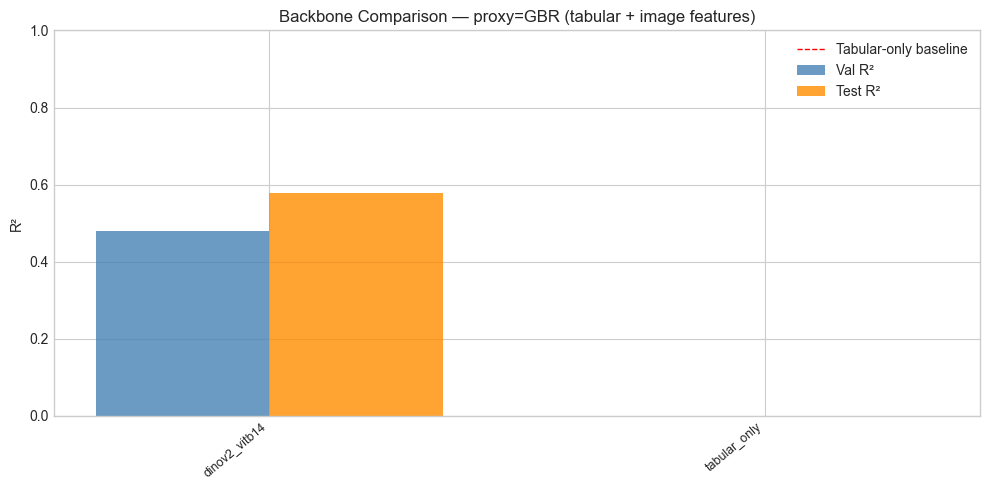


Recommended backbone: dinov2_vitb14  (test R²=0.5778)
Set BACKBONE='dinov2_vitb14' in cell 21 to use it for training.


In [19]:
# Backbone comparison — trains a fixed proxy regressor (from hyperparams.json,
# preference GBR > KNN > RF > ExtraTrees > XGB > ABR) once per cached backbone.
# Only runs backbones whose cache file exists (skips missing ones silently).
# Uses the same train/val/test split as the main pipeline for a fair comparison.

import os, gc
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score as _r2
import re as _re3
from collections import defaultdict

CACHE_DIR = os.path.abspath("../data/private_only_debug_lowres")
_F_RE2    = _re3.compile(r'_F_\d+\.[a-z]+$', _re3.IGNORECASE)

def _align_cache(cache_path, df_c1, idx_train, idx_val, idx_test):
    """Load cache and return (X_train, X_val, X_test) aligned to df_c1."""
    data      = np.load(cache_path, allow_pickle=True)
    X_cache   = data["X"].astype(np.float32)
    filenames = list(data["filenames"])

    id_to_idx = defaultdict(list)
    for i, fname in enumerate(filenames):
        rid = _re3.sub(r'[-\s]+', '_', _F_RE2.sub('', os.path.basename(fname)).strip().lower())
        id_to_idx[rid].append(i)

    feat_dim = X_cache.shape[1]
    X_aligned = np.full((len(df_c1), feat_dim), np.nan, dtype=np.float32)
    for row_idx, row_id in enumerate(
            df_c1['id'].astype(str).str.strip().str.lower().str.replace(r'[-\s]+', '_', regex=True)):
        idxs = id_to_idx.get(row_id, [])
        if idxs:
            X_aligned[row_idx] = X_cache[idxs].mean(axis=0)

    col_means = np.nanmean(X_aligned, axis=0)
    nan_mask  = np.isnan(X_aligned).any(axis=1)
    X_aligned[nan_mask] = col_means
    return X_aligned[idx_train], X_aligned[idx_val], X_aligned[idx_test]

# ── Pick a stable proxy regressor from the hyperparam store ──────────────
# This cell runs in §4c (before the larger CV sweep in §6b), so it loads
# the manifest itself and defines a minimal local factory rather than
# depending on cell 37. Preference order favours fast, low-variance models.
from src import hyperparams as _hp_4c
from sklearn.ensemble import (RandomForestRegressor as _RF4, ExtraTreesRegressor as _ET4,
                              GradientBoostingRegressor as _GBR4)
from sklearn.neighbors import KNeighborsRegressor as _KNN4
from sklearn.svm import SVR as _SVR4
try:
    from xgboost import XGBRegressor as _XGB4
    _HAS_XGB4 = True
except ImportError:
    _HAS_XGB4 = False

_PROXY_PREFERENCE = ['GBR', 'XGB']  # debug notebook compares only these two
_HP_SCOPE_4C      = 'dp_steel'
_saved_params_4c  = _hp_4c.load(_HP_SCOPE_4C)

def _build_proxy_4c(name, params):
    p = dict(params)
    if name in ('RF', 'RandomForest'):
        return _RF4(**p, random_state=42, n_jobs=-1)
    if name == 'ExtraTrees':
        return _ET4(**p, random_state=42, n_jobs=-1)
    if name in ('GBR', 'GradientBoosting'):
        return MultiOutputRegressor(_GBR4(**p, random_state=42))
    if name in ('ABR', 'AdaBoost'):
        md = p.pop('max_depth', 3)
        return MultiOutputRegressor(AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=md), **p, random_state=42))
    if name == 'XGB' and _HAS_XGB4:
        return MultiOutputRegressor(_XGB4(**p, random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0))
    if name in ('KNN', 'KNeighbors'):
        return MultiOutputRegressor(_KNN4(**p))
    if 'SVR' in name:
        kernel = 'linear' if 'linear' in name.lower() else 'rbf'
        return MultiOutputRegressor(_SVR4(kernel=kernel, **p))
    raise ValueError(f'Unknown model in store: {name!r}')

def _make_proxy():
    for _n in _PROXY_PREFERENCE:
        if _saved_params_4c and _n in _saved_params_4c:
            _p = dict(_saved_params_4c[_n].get('params', {}))
            print(f"  proxy regressor: {_n} (from store, scope={_HP_SCOPE_4C})")
            return _build_proxy_4c(_n, _p), _n
    print("  proxy regressor: GBR (fallback default — store empty)")
    return MultiOutputRegressor(_GBR4(n_estimators=100, max_depth=3,
                                      random_state=42)), 'GBR'

_PROXY_TEMPLATE, _PROXY_NAME = _make_proxy()
from sklearn.base import clone as _clone_proxy

def _make_abr():
    # Name kept for back-compat with code below; returns a fresh proxy clone.
    return _clone_proxy(_PROXY_TEMPLATE)

results = {}  # backbone -> {val_r2, test_r2, feat_dim}

# Pinned to dinov2_vitb14 — see notebook header. Other backbones are skipped
# even if their caches exist on disk.
_BACKBONES_TO_COMPARE = ['dinov2_vitb14']
for backbone_name in _BACKBONES_TO_COMPARE:
    cache_path = os.path.join(CACHE_DIR, f'image_cache_{backbone_name}.npz')
    if not os.path.exists(cache_path):
        print(f"  skip {backbone_name}: cache missing at {cache_path}")
        continue

    Xi_tr, Xi_vl, Xi_te = _align_cache(cache_path, df_c1, idx_train, idx_val, idx_test)
    feat_dim = Xi_tr.shape[1]

    X_tr = np.concatenate([Xi_tr, X_tab_train], axis=1)
    X_vl = np.concatenate([Xi_vl, X_tab_val],   axis=1)
    X_te = np.concatenate([Xi_te, X_tab_test],   axis=1)

    model = _make_abr()
    model.fit(X_tr, Y_train)

    val_r2  = _r2(Y_val,  model.predict(X_vl), multioutput='uniform_average')
    test_r2 = _r2(Y_test, model.predict(X_te), multioutput='uniform_average')
    results[backbone_name] = {'val_r2': val_r2, 'test_r2': test_r2, 'feat_dim': feat_dim}
    del model; gc.collect()

# Tabular-only baseline
model_tab = _make_abr()
model_tab.fit(X_tab_train, Y_train)
tab_val  = _r2(Y_val,  model_tab.predict(X_tab_val),  multioutput='uniform_average')
tab_test = _r2(Y_test, model_tab.predict(X_tab_test), multioutput='uniform_average')
results['tabular_only'] = {'val_r2': tab_val, 'test_r2': tab_test, 'feat_dim': 0}

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Backbone':<22} {'feat_dim':>9} {'val R²':>8} {'test R²':>9}")
print("-" * 52)
for name, m in sorted(results.items(), key=lambda x: -x[1]['test_r2']):
    marker = " ◀ best" if m['test_r2'] == max(v['test_r2'] for v in results.values()) else ""
    print(f"{name:<22} {m['feat_dim']:>9} {m['val_r2']:>8.4f} {m['test_r2']:>9.4f}{marker}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
names    = sorted(results, key=lambda x: -results[x]['test_r2'])
val_r2s  = [results[n]['val_r2']  for n in names]
test_r2s = [results[n]['test_r2'] for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.9), 5))
ax.bar(x - w/2, val_r2s,  w, label='Val R²',  alpha=0.8, color='steelblue')
ax.bar(x + w/2, test_r2s, w, label='Test R²', alpha=0.8, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title(f'Backbone Comparison — proxy={_PROXY_NAME} (tabular + image features)')
ax.axhline(tab_test, color='red', linestyle='--', linewidth=1, label='Tabular-only baseline')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

best = max(results, key=lambda x: results[x]['test_r2'])
print(f"\nRecommended backbone: {best}  (test R²={results[best]['test_r2']:.4f})")
print(f"Set BACKBONE='{best}' in cell 21 to use it for training.")

## 5. Model Training & Evaluation

Multi-output regression with 2 targets (Cycle 1 HoldingTemp + HoldingTime):
- **Random Forest**: Native multi-output support
- **Gradient Boosting**: Wrapped in MultiOutputRegressor
- **AdaBoost**: Wrapped in MultiOutputRegressor

**Note**: Learning curves (`staged_predict`) are only available for single-output boosting models, so they are skipped for this multi-output task.

In [20]:
# Targets are already split (Y_train/Y_val/Y_test set in cell 13)
Y = Y_c1  # full array kept for reference

print(f"Target columns: {target_columns}")
for i, name in enumerate(target_columns):
    print(f"  {name}: range=[{Y[:, i].min():.1f}, {Y[:, i].max():.1f}], "
          f"mean={Y[:, i].mean():.1f}, std={Y[:, i].std():.1f}")
print()
print(f"Split sizes: train={len(Y_train)}, val={len(Y_val)}, test={len(Y_test)}")


Target columns: ['cycle1_holdingtemp_degc', 'cycle1_holdingtime_min']
  cycle1_holdingtemp_degc: range=[740.0, 860.0], mean=793.9, std=41.9
  cycle1_holdingtime_min: range=[10.0, 30.0], mean=19.5, std=8.5

Split sizes: train=320, val=57, test=67


In [21]:
# Combine CNN image, morphological, and tabular features per split.
# Each stream is optional — the cell degrades gracefully if any is absent.

parts_train, parts_val, parts_test = [], [], []
dim_log = []

if X_img_train is not None:
    parts_train.append(X_img_train)
    parts_val.append(X_img_val)
    parts_test.append(X_img_test)
    dim_log.append(f"{X_img_train.shape[1]} (CNN image)")

if X_morph_train is not None:
    parts_train.append(X_morph_train)
    parts_val.append(X_morph_val)
    parts_test.append(X_morph_test)
    dim_log.append(f"{X_morph_train.shape[1]} (morphological)")

parts_train.append(X_tab_train)
parts_val.append(X_tab_val)
parts_test.append(X_tab_test)
dim_log.append(f"{X_tab_train.shape[1]} (tabular)")

X_train = np.concatenate(parts_train, axis=1)
X_val   = np.concatenate(parts_val,   axis=1)
X_test  = np.concatenate(parts_test,  axis=1)

print("Feature streams combined:")
print("  " + " + ".join(dim_log) + f" = {X_train.shape[1]} total")
print(f"Shapes — train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

# ── Impute NaN rows from missing image/morph caches ────────────────────
# X_img and X_morph return NaN for IDs without cached features; GBR/ABR/
# XGB don't accept NaN. Fit median imputer on train only (no leakage),
# apply to all three splits. Skip silently if there's nothing to impute.
if np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any():
    from sklearn.impute import SimpleImputer
    _imp = SimpleImputer(strategy="median")
    X_train = _imp.fit_transform(X_train)
    X_val   = _imp.transform(X_val)
    X_test  = _imp.transform(X_test)
    print(f"Imputed NaN rows from missing image/morph caches "
          f"(median per feature, fit on train only).")


Feature streams combined:
  768 (CNN image) + 33 (morphological) + 118 (tabular) = 919 total
Shapes — train=(320, 919), val=(57, 919), test=(67, 919)
Imputed NaN rows from missing image/morph caches (median per feature, fit on train only).


In [22]:
# Create a minimal config for the trainer
config = Config(
    random_seed=42,
    model_dir='../models'
)

# Initialize trainer with configurable n_estimators
trainer = ModelTrainer(config, n_estimators=100)  # Reduced for faster demo

print(f"Model Trainer initialized:")
print(f"  Random seed: {config.random_seed}")
print(f"  N estimators: {trainer.n_estimators}")
print(f"  Model directory: {config.model_dir}")

Model Trainer initialized:
  Random seed: 42
  N estimators: 100
  Model directory: ../models


In [23]:
# Data is already split in cell 13 — no need to re-split here.
print(f"Data splits:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")


Data splits:
  Train: (320, 919)
  Val:   (57, 919)
  Test:  (67, 919)


In [24]:
# Train all models and track learning curves
print("\nTraining ensemble models...")
print("=" * 60)

best_model_name = trainer.train_and_evaluate(
    X_train, Y_train,
    X_val, Y_val,
    target_columns,
    track_learning_curves=True  # Enable learning curve tracking
)


Training ensemble models...
Building models for 2 target(s) with 100 estimators...

Training RF...
Validation: R2=0.4514, MAE=10.5068, RMSE=14.9383
  cycle1_holdingtemp_degc: R2=0.735, MAE=14.769, RMSE=19.788
  cycle1_holdingtime_min: R2=0.168, MAE=6.245, RMSE=7.398

Training GBR...
Validation: R2=0.3170, MAE=11.0804, RMSE=15.9939
  cycle1_holdingtemp_degc: R2=0.701, MAE=15.139, RMSE=21.010
  cycle1_holdingtime_min: R2=-0.067, MAE=7.022, RMSE=8.377

Training ABR...
Validation: R2=0.3106, MAE=11.1183, RMSE=16.2852
  cycle1_holdingtemp_degc: R2=0.689, MAE=15.219, RMSE=21.453
  cycle1_holdingtime_min: R2=-0.067, MAE=7.018, RMSE=8.377

✓ Best model: RF (R2=0.4514)


In [25]:
# Learning curves are not available for multi-output models (staged_predict requires single output)
# This cell will report "No learning histories" which is expected behavior
print("Learning Curves:")
print("=" * 60)
print("Skipped: staged_predict is not available for multi-output boosting models.")
print("Learning curves are only supported when n_targets == 1.")

Learning Curves:
Skipped: staged_predict is not available for multi-output boosting models.
Learning curves are only supported when n_targets == 1.


In [26]:
# Evaluate all models on test set
test_results = trainer.evaluate_all_on_test(X_test, Y_test, target_columns)


Test Set Evaluation - All Models

RF:
  R2=0.5342, MAE=11.4469, RMSE=15.1530
    cycle1_holdingtemp_degc: R2=0.793, MAE=15.627, RMSE=19.913
    cycle1_holdingtime_min: R2=0.275, MAE=7.267, RMSE=7.918

GBR:
  R2=0.4060, MAE=11.4425, RMSE=14.9557
    cycle1_holdingtemp_degc: R2=0.812, MAE=14.230, RMSE=18.996
    cycle1_holdingtime_min: R2=-0.000, MAE=8.655, RMSE=9.300

ABR:
  R2=0.3708, MAE=12.8240, RMSE=17.0386
    cycle1_holdingtemp_degc: R2=0.743, MAE=16.991, RMSE=22.227
    cycle1_holdingtime_min: R2=-0.001, MAE=8.657, RMSE=9.304

✓ Best on test: RF (R2=0.5342)


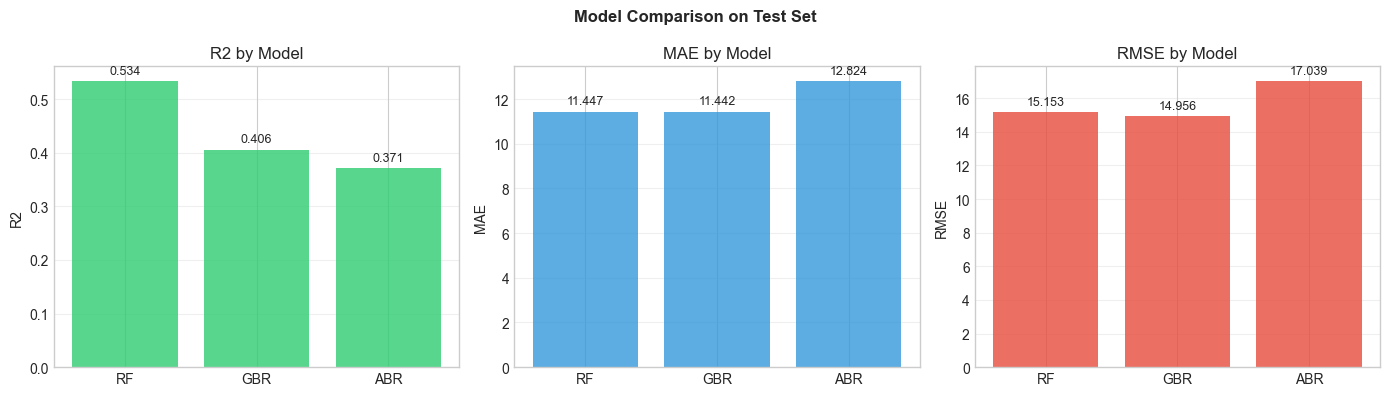

<Figure size 640x480 with 0 Axes>

In [27]:
# Plot model comparison
trainer.plot_test_comparison(show=True)
# Save model comparison figure to run directory
try:
    import matplotlib.pyplot as _plt_rc
    _plt_rc.savefig(str(_run_dir / "model_comparison.png"), dpi=150, bbox_inches="tight")
except Exception:
    pass


## 6b. Model Improvement Techniques

Three techniques applied to improve reliability on this small dataset:
- **Cross-validation** — more stable R² estimate than a single val split; model params loaded from store when available
- **Load from store** — best model hyperparams and preprocessing config loaded from  and  (written by  / )
- **Feature importance pruning** — remove low-signal features that add noise
- **SMOGN tabular augmentation** — synthesise new samples for underrepresented target ranges


In [28]:
# ── Load saved hyperparams (written by bayes_tuning.ipynb) ───────────────────
# Build the CV sweep dynamically from whatever models the latest tuning run
# produced — no hardcoded {RF, GBR, ABR, ExtraTrees}. If a tuning run added
# (or dropped) a model, this cell tracks it.
_HP_SCOPE     = "dp_steel"
_saved_params = hp.load(_HP_SCOPE)
if _saved_params:
    print(f"Loaded saved hyperparams for {len(_saved_params)} model(s) "
          f"(scope={_HP_SCOPE}): {list(_saved_params.keys())}")
else:
    print(f"No saved hyperparams found for scope={_HP_SCOPE} — "
          f"run bayes_tuning.ipynb first or accept the empty CV sweep.")

# ── CV protocol ───────────────────────────────────────────────────────────────
# With ~100 samples a single val split can swing ±0.1 R² depending on which
# 13 samples land in it. RepeatedKFold gives a much more reliable estimate.
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (AdaBoostRegressor, RandomForestRegressor,
                               GradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, r2_score as _r2_score
try:
    from xgboost import XGBRegressor
    _XGB_OK = True
except ImportError:
    _XGB_OK = False

_multi_r2 = make_scorer(_r2_score, multioutput="uniform_average")

# Use the full Cycle 1 feature matrix (no test hold-out — CV handles it).
X_full = np.concatenate([X_img_train, X_tab_train], axis=1) if X_img_train is not None else X_tab_train
X_full_all = np.vstack([X_full,
                        (np.concatenate([X_img_val, X_tab_val], axis=1) if X_img_val is not None else X_tab_val),
                        (np.concatenate([X_img_test, X_tab_test], axis=1) if X_img_test is not None else X_tab_test)])
Y_full_all = np.vstack([Y_train, Y_val, Y_test])

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)


# ─────────────────────────────────────────────────────────────────────────────
# Shared factory: build any supported regressor from a stored params dict.
# Reused by cell 38. Keep this in cell 37 so downstream cells inherit it.
# ─────────────────────────────────────────────────────────────────────────────
def _build_from_params(name: str, params: dict):
    """Construct an sklearn-compatible estimator for *name* using *params*.

    Mirrors the search space defined in bayes_tuning.ipynb's build_model().
    Wraps single-output learners in MultiOutputRegressor so they can predict
    both HoldingTemp and HoldingTime in one shot.
    """
    p = dict(params)  # don't mutate caller's dict
    base = name.replace("_pruned", "")

    if base in ("RF", "RandomForest"):
        return RandomForestRegressor(**p, random_state=42, n_jobs=-1)

    if base == "ExtraTrees":
        return ExtraTreesRegressor(**p, random_state=42, n_jobs=-1)

    if base in ("GBR", "GradientBoosting"):
        return MultiOutputRegressor(GradientBoostingRegressor(**p, random_state=42))

    if base in ("ABR", "AdaBoost"):
        md = p.pop("max_depth", 3)
        return MultiOutputRegressor(AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=md),
            **p, random_state=42))

    if base == "XGB":
        if not _XGB_OK:
            raise RuntimeError("XGBoost not installed but XGB params loaded from store.")
        return MultiOutputRegressor(XGBRegressor(
            **p, random_state=42, n_jobs=-1, tree_method='hist',
            verbosity=0))

    if base in ("KNN", "KNeighbors"):
        return MultiOutputRegressor(KNeighborsRegressor(**p))

    if "SVR" in base or base == "SVM":
        kernel = "linear" if "linear" in base.lower() else "rbf"
        return MultiOutputRegressor(SVR(kernel=kernel, **p))

    raise ValueError(f"Unknown model name in store: {name!r}")


# ── Build cv_models — debug notebook restricts to {GBR, XGB} only ────────────
# This notebook intentionally compares two regressors. Use store params when
# the manifest has them; otherwise fall back to sensible defaults so the sweep
# still runs without bayes_tuning being executed first.
_DEBUG_REGRESSORS = ['GBR', 'XGB']
cv_models = {}
for _name in _DEBUG_REGRESSORS:
    if _saved_params and _name in _saved_params:
        _params = _saved_params[_name].get('params', {})
        try:
            cv_models[_name] = _build_from_params(_name, _params)
            print(f"  {_name:<12} [store]    params={_params}")
        except Exception as e:
            print(f"  {_name:<12} [skipped]  {e}")
    else:
        # Defaults match bayes_tuning.ipynb's search-space midpoints.
        if _name == 'GBR':
            cv_models[_name] = MultiOutputRegressor(GradientBoostingRegressor(
                n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))
            print(f"  {_name:<12} [default]  n_estimators=200, max_depth=3, lr=0.05")
        elif _name == 'XGB':
            if not _XGB_OK:
                print(f"  {_name:<12} [skipped]  xgboost not installed")
                continue
            cv_models[_name] = MultiOutputRegressor(XGBRegressor(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                random_state=42, n_jobs=-1, tree_method='hist', verbosity=0))
            print(f"  {_name:<12} [default]  n_estimators=200, max_depth=4, lr=0.05")

cv_scores = {}  # name -> score array (consumed by metrics logger downstream)
print(f"\nCross-validation results (RepeatedKFold 5x10) on {X_full_all.shape}:")
print("=" * 60)
for _name, _model in cv_models.items():
    cv_scores[_name] = cross_val_score(_model, X_full_all, Y_full_all, cv=cv,
                                        scoring=_multi_r2, n_jobs=-1)
    print(f"  {_name:<12} R² = {cv_scores[_name].mean():.4f} ± {cv_scores[_name].std():.4f}  "
          f"(min={cv_scores[_name].min():.3f}, max={cv_scores[_name].max():.3f})")


Loaded saved hyperparams for 3 model(s) (scope=dp_steel): ['XGB', 'KNN', 'GBR']
  GBR          [store]    params={'n_estimators': 403, 'learning_rate': 0.03498995934771926, 'max_depth': 7, 'subsample': 0.8451737123346558, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
  XGB          [store]    params={'n_estimators': 361, 'learning_rate': 0.026425889648127254, 'max_depth': 4, 'subsample': 0.9366164137716618, 'colsample_bytree': 0.5175150753005386, 'min_child_weight': 1, 'reg_alpha': 3.106909017036473, 'reg_lambda': 0.7854786803364849, 'gamma': 0.0420474675569703}

Cross-validation results (RepeatedKFold 5x10) on (444, 886):
  GBR          R² = 0.6434 ± 0.0329  (min=0.580, max=0.706)
  XGB          R² = 0.7670 ± 0.0295  (min=0.705, max=0.834)


In [29]:
# ── Pick the best model from the hyperparam store + benchmark results ───────
# Hyperparams come from bayes_tuning.ipynb → runs/hyperparams.json (scope=dp_steel).
# Best preprocessing / regressor come from pipeline_benchmark.ipynb →
# runs/benchmark_results.csv. _build_from_params() is defined in cell 37.

import os as _os
import pandas as _pd
from sklearn.base import clone as _clone

# ── 1. Hyperparam store (already loaded in cell 37 as _saved_params) ──────────
if _saved_params:
    print(f"Hyperparam store loaded for scope=\"{_HP_SCOPE}\":")
    for _n, _v in _saved_params.items():
        _r2 = _v.get("tuned_cv_r2", _v.get("best_cv_r2", "?"))
        print(f"  {_n:<14}  tuned_cv_r2={_r2}")
else:
    print(f"No saved hyperparams for scope=\"{_HP_SCOPE}\" — falling back to CV winner.")

# ── 2. Optional benchmark results (preprocessing/regressor winners) ──────────
_bench_path = _os.path.join(_os.path.dirname(_os.path.abspath("runs")), "runs", "benchmark_results.csv")
_bench_model   = None
_bench_preproc = None
if _os.path.exists(_bench_path):
    _df_bench = _pd.read_csv(_bench_path)
    _reg_rows = _df_bench[_df_bench["stage"] == "regressor"]
    _pre_rows = _df_bench[_df_bench["stage"] == "preprocessing"]
    if not _reg_rows.empty:
        _bench_model = _reg_rows.sort_values("mean_r2", ascending=False).iloc[0]["config"]
    if not _pre_rows.empty:
        _bench_preproc = _pre_rows.sort_values("mean_r2", ascending=False).iloc[0]["config"]
    print(f"Benchmark results: best regressor={_bench_model}  best preprocessing={_bench_preproc}")

# ── 3. Resolve which model to use ─────────────────────────────────────────────
# Priority:
#   (a) benchmark winner that's also in the store
#   (b) store winner (hp.best_model)
#   (c) CV winner from cell 37 (cv_scores)
#   (d) hardcoded RF fallback
_use_name = None
if _bench_model and _bench_model in _saved_params:
    _use_name = _bench_model
elif _saved_params:
    _use_name, _ = hp.best_model(_HP_SCOPE)
elif cv_scores:
    _use_name = max(cv_scores, key=lambda k: cv_scores[k].mean())
else:
    _use_name = "RF"

_use_params = dict(_saved_params.get(_use_name, {}).get("params", {})) if _saved_params else {}
print(f"Selected model    : {_use_name}")
print(f"Source of params  : {'store' if _use_params else 'defaults'}")

# ── 4. Build the chosen estimator (factory comes from cell 37) ────────────────
if _use_params:
    _best_estimator = _build_from_params(_use_name, _use_params)
else:
    _best_estimator = RandomForestRegressor(n_estimators=200, max_features="sqrt",
                                             min_samples_leaf=3, random_state=42, n_jobs=-1)

# ── 5. Cross-validate the chosen model ────────────────────────────────────────
CV_FULL = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
print(f"\nCross-validating {_use_name} (RepeatedKFold 5×10)...")
_full_sc    = cross_val_score(_best_estimator, X_full_all, Y_full_all,
                               cv=CV_FULL, scoring=_multi_r2, n_jobs=-1)
_untuned_r2 = cv_scores.get(_use_name, _full_sc).mean()
_delta      = _full_sc.mean() - _untuned_r2 if _use_name in cv_scores else 0.0
print(f"  CV R² = {_full_sc.mean():.4f} ± {_full_sc.std():.4f}  "
      f"(delta vs cell-37 sweep: {_delta:+.4f})")

# ── 6. Set variables consumed downstream (predictions, metrics logger) ───────
best_tuned_name = _use_name
best_tuned_r2   = float(_full_sc.mean())
bayes_eval = {
    _use_name: {
        "untuned_r2": float(_untuned_r2),
        "tuned_r2":   best_tuned_r2,
        "tuned_std":  float(_full_sc.std()),
        "delta":      float(_delta),
        "params":     _use_params,
    }
}

# Fit on train split so prediction cells can reuse it.
best_tuned_model = _clone(_best_estimator)
best_tuned_model.fit(X_train, Y_train)

print(f"\nbest_tuned_name = {best_tuned_name}")
print(f"best_tuned_r2   = {best_tuned_r2:.4f}")
if _bench_preproc:
    print(f"Benchmark preprocessing: {_bench_preproc}")


Hyperparam store loaded for scope="dp_steel":
  XGB             tuned_cv_r2=0.6412546068125526
  KNN             tuned_cv_r2=0.6669810846389674
  GBR             tuned_cv_r2=0.5500367140963259
Selected model    : KNN
Source of params  : store

Cross-validating KNN (RepeatedKFold 5×10)...
  CV R² = 0.8266 ± 0.0397  (delta vs cell-37 sweep: +0.0000)

best_tuned_name = KNN
best_tuned_r2   = 0.8266


Importance source: GBR (params from store)
Keeping 709/886 features (dropped bottom 20%)

Pruning comparison — test R² (uniform average)
Model              Full   Pruned    Delta
--------------------------------------------
  GBR            0.5778   0.5543  -0.0235
  XGB            0.4756   0.4699  -0.0058


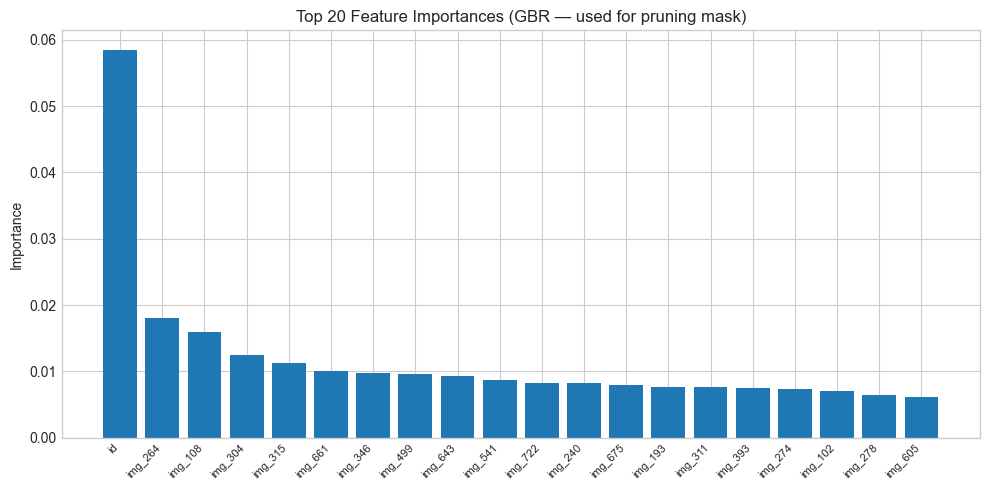

In [30]:
# ── Feature importance pruning ─────────────────────────────────────────────
# Use feature importances from a manifest-driven tree model to derive a
# keep_mask (bottom 20% dropped), then compare full vs pruned across cv_models.
#
# Importance source picked from _saved_params (cell 37) using preference order
# below. KNN and SVR don't expose feature_importances_, so we walk past them.
# If nothing usable is in the store, the whole cell is skipped — we don't fall
# back to a hardcoded RF since that would report importances from an untuned
# model and silently mislead anyone reading the resulting bar chart.
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score as _r2

X_tr = np.concatenate([X_img_train, X_tab_train], axis=1) if X_img_train is not None else X_tab_train
X_vl = np.concatenate([X_img_val,   X_tab_val],   axis=1) if X_img_val  is not None else X_tab_val
X_te = np.concatenate([X_img_test,  X_tab_test],  axis=1) if X_img_test is not None else X_tab_test

# Tree-ish models that expose feature_importances_, ranked by usefulness here.
_IMP_PREFERENCE = ['GBR', 'XGB', 'ExtraTrees', 'RF', 'ABR']
_imp_name       = next((n for n in _IMP_PREFERENCE if n in (_saved_params or {})), None)

if _imp_name is None:
    print(f"No tree-based model in _saved_params (have: "
          f"{list((_saved_params or {}).keys())}); skipping feature-importance cell. "
          f"Re-run bayes_tuning with one of {_IMP_PREFERENCE} included to enable.")
else:
    # ── Step 1: derive importance mask from the chosen model ────────────────
    _imp_params = dict(_saved_params[_imp_name].get("params", {}))
    _imp_model  = _build_from_params(_imp_name, _imp_params)
    print(f"Importance source: {_imp_name} (params from store)")
    _imp_model.fit(X_tr, Y_train)

    # MultiOutputRegressor wraps GBR/XGB/ABR for the dual-target Y; pull the
    # per-target importances and average them so the mask is target-agnostic.
    if hasattr(_imp_model, "estimators_"):
        per_target_imp = np.vstack([est.feature_importances_
                                    for est in _imp_model.estimators_])
        importances = per_target_imp.mean(axis=0)
    else:
        importances = _imp_model.feature_importances_

    threshold = np.percentile(importances, 20)
    keep_mask = importances >= threshold
    print(f"Keeping {keep_mask.sum()}/{len(importances)} features (dropped bottom 20%)")

    # ── Step 2: full vs pruned test R² for all cv_models ────────────────────
    print("\nPruning comparison — test R² (uniform average)")
    print(f"{'Model':<14} {'Full':>8} {'Pruned':>8} {'Delta':>8}")
    print("-" * 44)
    for _name, _model in cv_models.items():
        _m_full   = copy.deepcopy(_model)
        _m_pruned = copy.deepcopy(_model)
        _m_full.fit(X_tr, Y_train)
        _m_pruned.fit(X_tr[:, keep_mask], Y_train)
        r2_full   = _r2(Y_test, _m_full.predict(X_te),                 multioutput="uniform_average")
        r2_pruned = _r2(Y_test, _m_pruned.predict(X_te[:, keep_mask]), multioutput="uniform_average")
        print(f"  {_name:<12} {r2_full:8.4f} {r2_pruned:8.4f} {r2_pruned - r2_full:+8.4f}")

    # ── Step 3: top-20 feature importance bar chart ─────────────────────────
    feat_names = (["img_" + str(i) for i in range(X_tr.shape[1] - X_tab_train.shape[1])]
                  if X_img_train is not None else []) + list(preprocessor.get_feature_names())
    top20_idx = np.argsort(importances)[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(20), importances[top20_idx])
    ax.set_xticks(range(20))
    ax.set_xticklabels([feat_names[i] if i < len(feat_names) else f"f{i}"
                        for i in top20_idx], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Top 20 Feature Importances ({_imp_name} — used for pruning mask)")
    ax.set_ylabel("Importance")
    plt.tight_layout()
    plt.show()


### 6b.1 Feature ranking — most relevant features (full ranked table)

The cell above uses tree feature_importances_ to derive a *pruning mask*. This
cell complements it by producing the **full ranked list** of features:

- Aggregates importances across both targets (per-target columns shown)
- Tags every feature with its source (`image`, `morph`, `tabular`) so you can
  see at a glance which stream dominates
- Adds **permutation importance** alongside tree feature_importances_, which
  is more reliable on this dataset because tree importance is biased toward
  high-cardinality features (CNN floats > tabular ints)
- Writes the full ranking to `<run_dir>/feature_ranking.csv`


Feature stream sizes — image: 768  morph: 33  tabular: 118  total: 919
Tree feature_importances_ source: GBR (refit locally — cell-39 importances did not match the 919-feature matrix)
Permutation importance model: KNN (best_tuned_model from cell 38)

Features ranked by: perm_imp_mean

Top 25 most relevant features:
------------------------------------------------------------------------------------------
 rank                           feature source  tree_imp_c1_holdingtemp  tree_imp_c1_holdingtime  tree_imp_mean  perm_imp_c1_holdingtemp  perm_imp_c1_holdingtime  perm_imp_mean
    1 morph_martensite_island_area_mean  morph                   0.0048                   0.0000         0.0024                   0.8153                   0.2304         0.5229
    2            morph_ferrite_area_std  morph                   0.0000                   0.0000         0.0000                   0.2185                   0.1607         0.1896
    3           morph_ferrite_area_mean  morph               

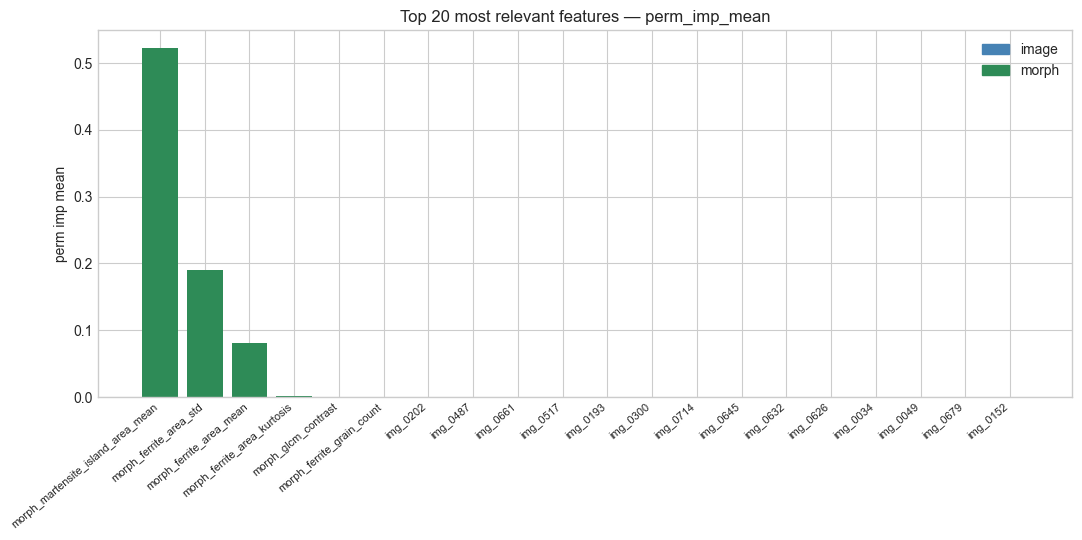


Saved full ranked table -> /Users/ayobamibamigboye/capstone/model/runs/debug_lowres/20260504_100001_f151/feature_ranking.csv
Saved bar chart          -> /Users/ayobamibamigboye/capstone/model/runs/debug_lowres/20260504_100001_f151/feature_ranking.png


In [31]:
# ── Feature ranking — most relevant features ────────────────────────────────
# Produces a full ranked table of features sorted by aggregate importance, with
# source tags (image / morph / tabular) and per-target columns. Uses the tree
# model from cell 39 if available, plus a permutation-importance pass on the
# best CV model so the ranking is less biased toward high-cardinality features.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score as _r2

# ── Build a full image+morph+tabular matrix for the ranking ─────────────────
# Cell 39's X_tr is image+tabular only (it skips morph). For this notebook
# the whole point is to evaluate morph features, so we (re)build a matrix
# that includes all three streams and rank against it. We also impute any
# residual NaNs (morph rows for IDs without images become NaN), fit on train
# only to avoid leakage. This is a local copy — it does not overwrite cell
# 39's X_tr because cell 39's pruning logic is intentionally tabular+image.

_parts_tr, _parts_te = [], []
_n_img   = X_img_train.shape[1]   if X_img_train   is not None else 0
_n_morph = X_morph_train.shape[1] if X_morph_train is not None else 0
_n_tab   = X_tab_train.shape[1]
if X_img_train is not None:
    _parts_tr.append(X_img_train);   _parts_te.append(X_img_test)
if X_morph_train is not None:
    _parts_tr.append(X_morph_train); _parts_te.append(X_morph_test)
_parts_tr.append(X_tab_train);       _parts_te.append(X_tab_test)
X_tr_rank = np.concatenate(_parts_tr, axis=1)
X_te_rank = np.concatenate(_parts_te, axis=1)

if np.isnan(X_tr_rank).any() or np.isnan(X_te_rank).any():
    _rank_imp = SimpleImputer(strategy="median")
    X_tr_rank = _rank_imp.fit_transform(X_tr_rank)
    X_te_rank = _rank_imp.transform(X_te_rank)

# Image features have no human-readable names — index them by position.
_img_names = [f"img_{i:04d}" for i in range(_n_img)]
# Morph features come from the canonical extractor name list.
try:
    from src.extraction.morphology import MorphologicalExtractor as _MorphExt
    _morph_names = list(_MorphExt.get_feature_names())[:_n_morph]
    if len(_morph_names) < _n_morph:
        _morph_names += [f"morph_{i:02d}" for i in range(len(_morph_names), _n_morph)]
except Exception:
    _morph_names = [f"morph_{i:02d}" for i in range(_n_morph)]
# Tabular feature names from the fitted preprocessor.
_tab_names = list(preprocessor.get_feature_names())

feat_names = _img_names + _morph_names + _tab_names
sources    = (["image"] * _n_img) + (["morph"] * _n_morph) + (["tabular"] * _n_tab)
assert len(feat_names) == X_tr_rank.shape[1], (
    f"feature-name length mismatch: names={len(feat_names)} cols={X_tr_rank.shape[1]}  "
    f"(image={_n_img} morph={_n_morph} tabular={_n_tab})")

print(f"Feature stream sizes — image: {_n_img}  morph: {_n_morph}  tabular: {_n_tab}  "
      f"total: {len(feat_names)}")

# ── Method 1: tree feature_importances_ (per-target + average) ─────────────
# Reuse the importance source that cell 39 picked; if cell 39 was skipped,
# fall back to fitting GBR with default params here so this cell still runs.
tree_imp_per_target = None
def _imp_matches(model, expected_dim):
    """Return per-target importances if the model's reported width matches *expected_dim*."""
    if model is None:
        return None
    if hasattr(model, "estimators_") and model.estimators_:
        per = np.vstack([est.feature_importances_ for est in model.estimators_])
    elif hasattr(model, "feature_importances_"):
        per = model.feature_importances_.reshape(1, -1)
    else:
        return None
    return per if per.shape[1] == expected_dim else None

try:
    _reused = _imp_matches(globals().get("_imp_model"), X_tr_rank.shape[1])
    if _reused is not None and globals().get("_imp_name"):
        tree_imp_per_target = _reused
        _tree_src = f"{_imp_name} (cell 39)"
    else:
        # Cell 39 trained on a different feature width (image+tabular only) —
        # refit GBR locally on the full image+morph+tabular matrix.
        from sklearn.ensemble import GradientBoostingRegressor
        from sklearn.multioutput import MultiOutputRegressor
        _fi_model = MultiOutputRegressor(GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42))
        _fi_model.fit(X_tr_rank, Y_train)
        tree_imp_per_target = np.vstack([est.feature_importances_
                                         for est in _fi_model.estimators_])
        _tree_src = ("GBR (refit locally — cell-39 importances did not match "
                     f"the {X_tr_rank.shape[1]}-feature matrix)")
    print(f"Tree feature_importances_ source: {_tree_src}")
except Exception as e:
    print(f"Tree importances unavailable: {e}")

# ── Method 2: permutation importance on the best CV model ──────────────────
# Permutation importance shuffles one feature at a time and measures the drop
# in test R². It's slower (one fit + n_features prediction passes per repeat)
# but unbiased toward high-cardinality features.
def _model_input_width(m):
    """Best-effort: return the n_features the model was fit on, or None."""
    for est in getattr(m, "estimators_", []) or [m]:
        for attr in ("n_features_in_",):
            if hasattr(est, attr):
                return int(getattr(est, attr))
    return None

_perm_model = None
try:
    from sklearn.base import clone as _clone
    if "best_tuned_model" in globals():
        _w = _model_input_width(best_tuned_model)
        if _w is None or _w == X_tr_rank.shape[1]:
            _perm_model = best_tuned_model
            _perm_src   = best_tuned_name + " (best_tuned_model from cell 38)"
        else:
            _perm_model = _clone(best_tuned_model)
            _perm_model.fit(X_tr_rank, Y_train)
            _perm_src = best_tuned_name + " (refit on full matrix — cell-38 width mismatch)"
    elif "_best_estimator" in globals():
        _perm_model = _clone(_best_estimator)
        _perm_model.fit(X_tr_rank, Y_train)
        _perm_src = _use_name + " (refit from cell 38)"
    else:
        _perm_src = None
except Exception as e:
    print(f"  permutation-model setup failed: {e}")
    _perm_src = None

perm_per_target = None
if _perm_model is not None:
    print(f"Permutation importance model: {_perm_src}")
    # Compute per-target by fitting two single-output passes — keeps things
    # interpretable even though it doubles the cost.
    perm_per_target = np.zeros((Y_train.shape[1], X_tr_rank.shape[1]))
    for t_idx, col in enumerate(target_columns):
        _r = permutation_importance(
            _perm_model, X_te_rank, Y_test[:, t_idx],
            n_repeats=10, random_state=42, n_jobs=-1,
            scoring=lambda m, X, y: _r2(y, m.predict(X)[:, t_idx]
                                           if m.predict(X).ndim == 2 else m.predict(X)),
        )
        perm_per_target[t_idx] = _r.importances_mean
else:
    print("Permutation importance skipped — no fitted CV model in scope.")

# ── Build the ranked DataFrame ─────────────────────────────────────────────
rows = []
for i, name in enumerate(feat_names):
    row = {"rank": None, "feature": name, "source": sources[i]}
    if tree_imp_per_target is not None:
        for t_idx, col in enumerate(target_columns):
            short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
            row[f"tree_imp_{short}"] = float(tree_imp_per_target[t_idx, i])
        row["tree_imp_mean"] = float(tree_imp_per_target[:, i].mean())
    if perm_per_target is not None:
        for t_idx, col in enumerate(target_columns):
            short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
            row[f"perm_imp_{short}"] = float(perm_per_target[t_idx, i])
        row["perm_imp_mean"] = float(perm_per_target[:, i].mean())
    rows.append(row)

df_rank = pd.DataFrame(rows)

# Pick the primary ranking signal: prefer permutation when available.
_rank_col = "perm_imp_mean" if "perm_imp_mean" in df_rank.columns else "tree_imp_mean"
df_rank = df_rank.sort_values(_rank_col, ascending=False).reset_index(drop=True)
df_rank["rank"] = df_rank.index + 1
print(f"\nFeatures ranked by: {_rank_col}")

# ── Top 25 readable table ──────────────────────────────────────────────────
_disp_cols = ["rank", "feature", "source"]
for c in df_rank.columns:
    if c.startswith(("tree_imp_", "perm_imp_")):
        _disp_cols.append(c)

print("\nTop 25 most relevant features:")
print("-" * 90)
print(df_rank[_disp_cols].head(25).to_string(index=False,
        float_format=lambda x: f"{x:7.4f}"))

# ── Per-source aggregate ───────────────────────────────────────────────────
print("\nAggregate importance by feature source:")
print("-" * 60)
agg = df_rank.groupby("source")[_rank_col].agg(["sum", "mean", "count"]).round(4)
agg["share_of_total"] = (agg["sum"] / agg["sum"].sum()).round(4)
print(agg.sort_values("sum", ascending=False).to_string())

# ── Top 20 bar chart, color-coded by source ───────────────────────────────
_top20    = df_rank.head(20)
_palette  = {"image": "steelblue", "morph": "seagreen", "tabular": "darkorange"}
_colors   = [_palette.get(s, "gray") for s in _top20["source"]]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(range(len(_top20)), _top20[_rank_col].values, color=_colors)
ax.set_xticks(range(len(_top20)))
ax.set_xticklabels(_top20["feature"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel(_rank_col.replace("_", " "))
ax.set_title(f"Top 20 most relevant features — {_rank_col}")
# Build a legend that matches the source colours actually present in top-20.
import matplotlib.patches as mpatches
_legend = [mpatches.Patch(color=c, label=s)
           for s, c in _palette.items() if s in _top20["source"].values]
ax.legend(handles=_legend, loc="upper right")
plt.tight_layout()
plt.savefig(str(_run_dir / "feature_ranking.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Save full ranked table ─────────────────────────────────────────────────
_rank_path = _run_dir / "feature_ranking.csv"
df_rank.to_csv(_rank_path, index=False)
print(f"\nSaved full ranked table -> {_rank_path}")
print(f"Saved bar chart          -> {_run_dir / 'feature_ranking.png'}")


In [32]:
# ── SMOGN tabular augmentation ────────────────────────────────────────────────
# Synthesises new tabular samples for underrepresented target ranges, then
# checks whether the augmentation changes test R². The evaluator model is
# picked from _saved_params (cell 37) — same preference order as cell 39 —
# so the test reflects the model the rest of the notebook actually uses.
#
# SMOGN itself only operates on tabular features, so both baseline and
# augmented runs use X_tab_* (no image features). Skips cleanly when SMOGN
# isn't installed or when no tree-based model is in the store.
try:
    import smogn
    import pandas as pd

    # SMOGN operates on a single target — run per target, take the larger
    # augmented set (more conservative — bigger variance reduction).
    df_aug_input = pd.DataFrame(X_tab_train,
                                columns=preprocessor.get_feature_names())
    df_aug_input[c1_temp_col] = Y_train[:, 0]
    df_aug_input[c1_time_col] = Y_train[:, 1]

    df_aug_temp = smogn.smoter(data=df_aug_input, y=c1_temp_col, k=3,
                                samp_method='balance', random_state=42)
    df_aug_time = smogn.smoter(data=df_aug_input, y=c1_time_col, k=3,
                                samp_method='balance', random_state=42)

    df_aug = df_aug_temp if len(df_aug_temp) >= len(df_aug_time) else df_aug_time
    feat_cols = preprocessor.get_feature_names()
    X_tab_train_aug = df_aug[feat_cols].values.astype(np.float32)
    Y_train_aug     = df_aug[[c1_temp_col, c1_time_col]].values.astype(np.float64)

    print(f"SMOGN augmentation: {len(Y_train)} -> {len(Y_train_aug)} training samples")

    # ── Pick the evaluator from the hyperparam store ────────────────────────
    # Prefer tree-based models (richer fit on tabular). KNN/SVR are valid too
    # but less informative for testing whether augmentation helps a real model.
    _SMOGN_PREFERENCE = ['GBR', 'XGB', 'ExtraTrees', 'RF', 'ABR', 'KNN']
    _eval_name = next((n for n in _SMOGN_PREFERENCE if n in (_saved_params or {})), None)

    if _eval_name is None:
        print(f"No usable model in _saved_params (have: "
              f"{list((_saved_params or {}).keys())}); skipping SMOGN evaluation. "
              f"Re-run bayes_tuning with one of {_SMOGN_PREFERENCE} included.")
    else:
        from sklearn.base import clone as _clone_smogn
        _eval_params = dict(_saved_params[_eval_name].get("params", {}))
        _eval_template = _build_from_params(_eval_name, _eval_params)
        print(f"Evaluator: {_eval_name} (params from store)")

        # Apples-to-apples: same model, same tabular-only feature set, only
        # the training data differs (original vs SMOGN-augmented).
        _m_base = _clone_smogn(_eval_template)
        _m_aug  = _clone_smogn(_eval_template)
        _m_base.fit(X_tab_train,     Y_train)
        _m_aug.fit (X_tab_train_aug, Y_train_aug)
        r2_base = _r2(Y_test, _m_base.predict(X_tab_test), multioutput='uniform_average')
        r2_aug  = _r2(Y_test, _m_aug.predict (X_tab_test), multioutput='uniform_average')

        print(f"{_eval_name} baseline (no aug)  test R2: {r2_base:.4f}")
        print(f"{_eval_name} + SMOGN aug        test R2: {r2_aug:.4f}")
        print(f"Delta from augmentation:        {r2_aug - r2_base:+.4f}")

except ImportError:
    print("smogn not installed -- run: pip install smogn")
    print("Skipping augmentation cell.")


smogn not installed -- run: pip install smogn
Skipping augmentation cell.


## 6. Predictions Visualization

Per-target predicted vs actual plots and residual analysis for the multi-output model.

In [33]:
# ── Top-3 model predictions ───────────────────────────────────────────────────
# Rank cv_models by mean CV R², pick top 3, fit each on train, predict on test.
import copy
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

_ranked = sorted(cv_scores.items(), key=lambda kv: kv[1].mean(), reverse=True)
_top3_names = [k for k, _ in _ranked[:3]]
print("Top 3 models by CV R²:")
for _n, _sc in _ranked[:3]:
    print(f"  {_n:<14} CV R² = {_sc.mean():.4f} ± {_sc.std():.4f}")

# Fit each top-3 model on the train split, predict on test
top3_preds   = {}   # name -> Y_pred (n_test × n_targets)
top3_metrics = {}   # name -> {R2, MAE, RMSE}
for _n in _top3_names:
    _m = copy.deepcopy(cv_models[_n])
    _m.fit(X_tr, Y_train)
    _yp = _m.predict(X_te)
    if _yp.ndim == 1:
        _yp = _yp.reshape(-1, 1)
    top3_preds[_n] = _yp
    top3_metrics[_n] = {
        "R2":   r2_score(Y_test,  _yp, multioutput="uniform_average"),
        "MAE":  mean_absolute_error(Y_test, _yp, multioutput="uniform_average"),
        "RMSE": float(np.sqrt(mean_squared_error(Y_test, _yp, multioutput="uniform_average"))),
    }

print("\nTest set metrics (top 3):")
print(f"  {'Model':<14} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("  " + "-" * 44)
for _n in _top3_names:
    m = top3_metrics[_n]
    print(f"  {_n:<14} {m['R2']:8.4f} {m['MAE']:10.4f} {m['RMSE']:10.4f}")

# Best of the three (for downstream residual / summary cells)
_best_name = max(top3_metrics, key=lambda k: top3_metrics[k]["R2"])
Y_pred      = top3_preds[_best_name]
print(f"\nBest of top 3: {_best_name}  (R² = {top3_metrics[_best_name]['R2']:.4f})")


Top 3 models by CV R²:
  XGB            CV R² = 0.7670 ± 0.0295
  GBR            CV R² = 0.6434 ± 0.0329

Test set metrics (top 3):
  Model                R²        MAE       RMSE
  --------------------------------------------
  XGB              0.4756    11.8474    15.6183
  GBR              0.5778    10.6161    14.5113

Best of top 3: GBR  (R² = 0.5778)


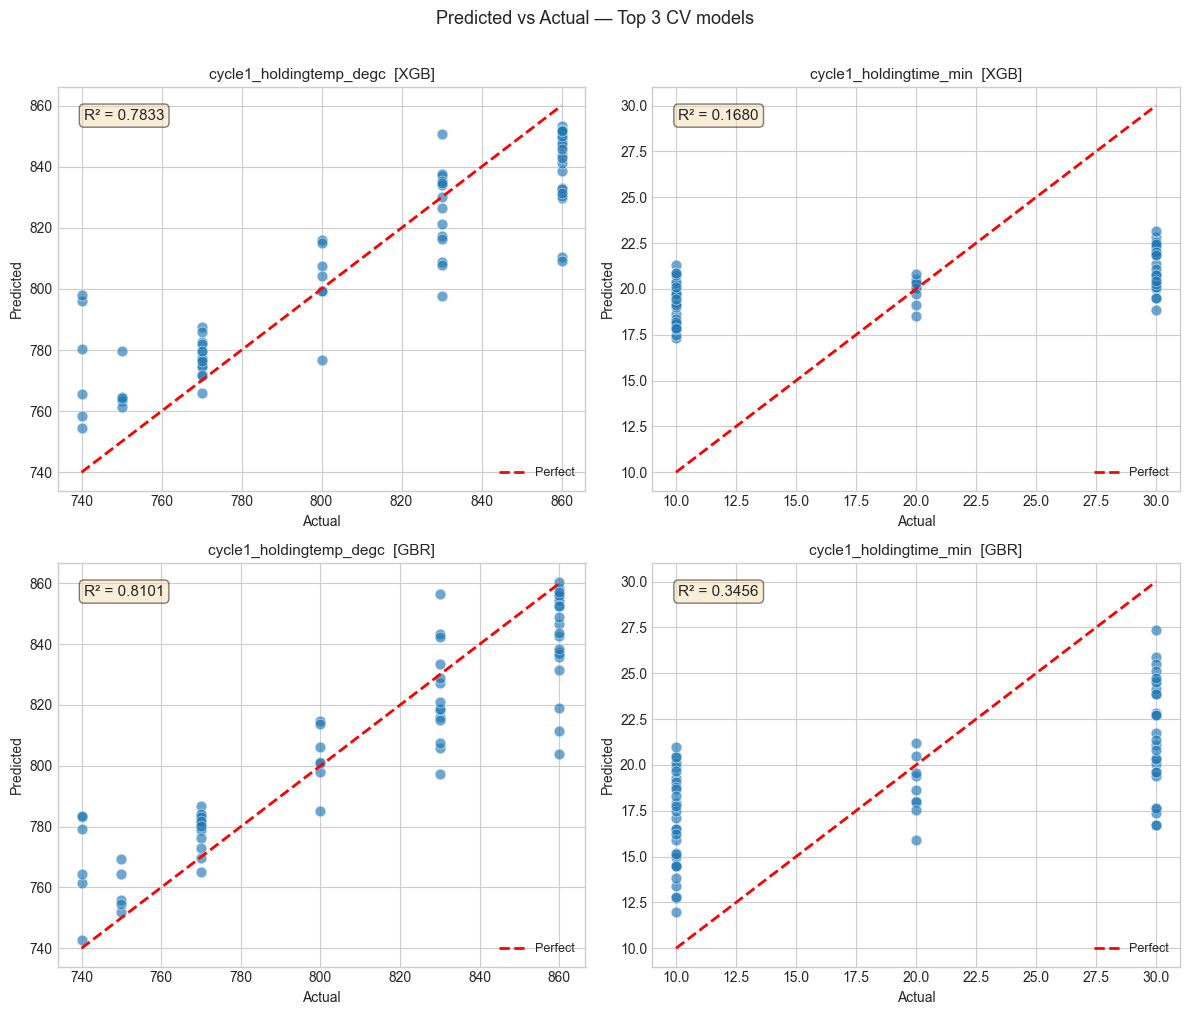

In [34]:
# ── Predicted vs actual — top 3 models, one row per model ────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

n_targets = len(target_columns)
fig, axes = plt.subplots(len(_top3_names), n_targets,
                         figsize=(6 * n_targets, 5 * len(_top3_names)),
                         squeeze=False)

for row, _n in enumerate(_top3_names):
    _yp = top3_preds[_n]
    for col_idx, col in enumerate(target_columns):
        ax = axes[row][col_idx]
        y_true = Y_test[:, col_idx]
        y_pred = _yp[:, col_idx]

        ax.scatter(y_true, y_pred, alpha=0.65, edgecolors="white", linewidth=0.5, s=60)
        mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Perfect")
        r2 = r2_score(y_true, y_pred)
        ax.annotate(f"R² = {r2:.4f}", xy=(0.05, 0.92), xycoords="axes fraction",
                    fontsize=11, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
        ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
        ax.set_title(f"{col}  [{_n}]", fontsize=11)
        ax.legend(fontsize=9)

plt.suptitle("Predicted vs Actual — Top 3 CV models", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


cycle1_holdingtemp_degc residuals (GBR): mean=1.26, std=19.05, min=-43.34, max=56.00
cycle1_holdingtime_min residuals (GBR): mean=0.57, std=7.50, min=-10.98, max=13.29


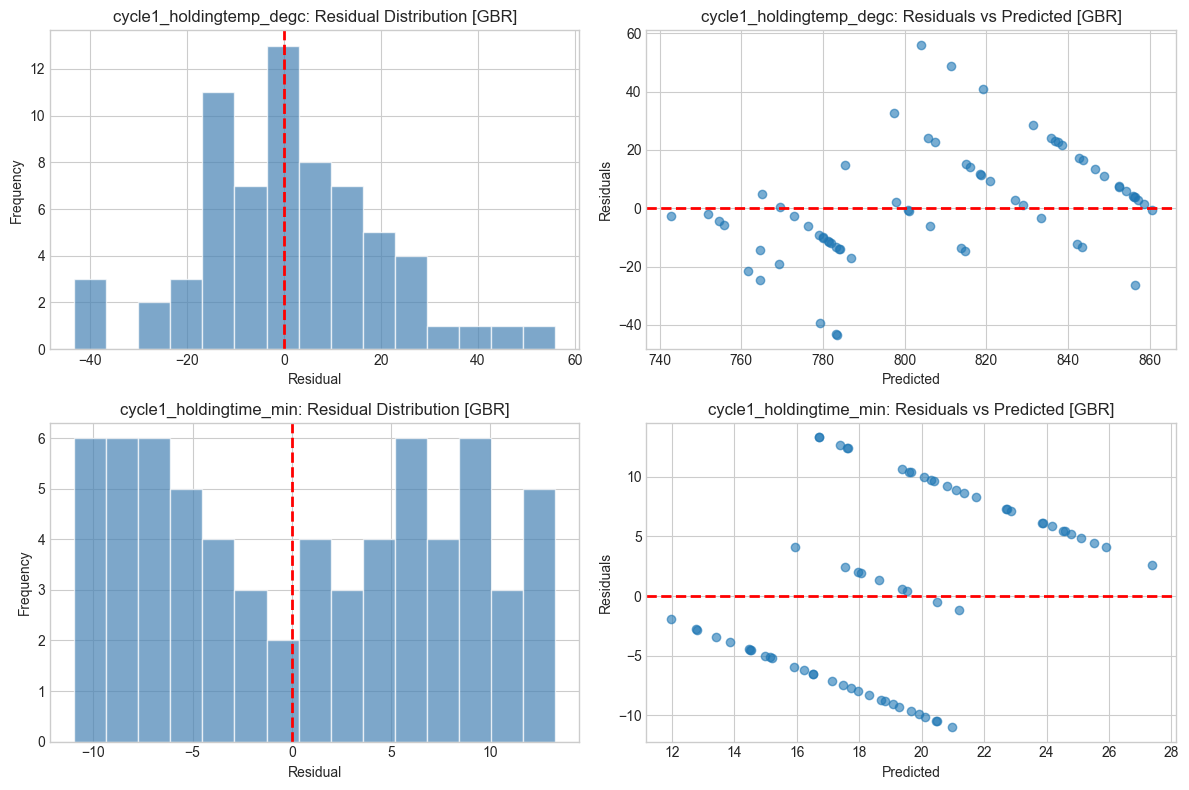

In [35]:
# ── Residual analysis — best of top 3 ────────────────────────────────────────
import matplotlib.pyplot as plt

n_targets = len(target_columns)
fig, axes = plt.subplots(n_targets, 2, figsize=(12, 4 * n_targets))
if n_targets == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(target_columns):
    residuals = Y_test[:, i] - Y_pred[:, i]

    axes[i, 0].hist(residuals, bins=15, color="steelblue", alpha=0.7, edgecolor="white")
    axes[i, 0].axvline(x=0, color="red", linestyle="--", linewidth=2)
    axes[i, 0].set_xlabel("Residual"); axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].set_title(f"{col}: Residual Distribution [{_best_name}]")

    axes[i, 1].scatter(Y_pred[:, i], residuals, alpha=0.6)
    axes[i, 1].axhline(y=0, color="red", linestyle="--", linewidth=2)
    axes[i, 1].set_xlabel("Predicted"); axes[i, 1].set_ylabel("Residuals")
    axes[i, 1].set_title(f"{col}: Residuals vs Predicted [{_best_name}]")

    print(f"{col} residuals ({_best_name}): mean={residuals.mean():.2f}, "
          f"std={residuals.std():.2f}, min={residuals.min():.2f}, max={residuals.max():.2f}")

plt.tight_layout()
plt.show()


### 6c. Outlier Test Predictions

Identifies test rows where the best-of-top-3 model predicts badly, and
**highlights the offending IDs** explicitly:

- residuals are converted to per-target z-scores (`(actual - pred) / std`)
- the row-level outlier score is `max(|z|)` across targets, so a row is flagged
  if it fails on **either** HoldingTemp or HoldingTime
- rows with `max(|z|) >= OUTLIER_Z_THRESHOLD` (default 2.0) are listed by ID
  with their alloy and per-target diagnostics, and rendered as red dots
  (annotated with their IDs) on the predicted-vs-actual scatter
- the full sorted table — including a boolean `is_outlier` column — is saved
  to `<run_dir>/outlier_test_predictions.csv`

Tweak `OUTLIER_Z_THRESHOLD` in the cell to widen or narrow the flag set.


Outlier test predictions  (model=GBR, threshold |z| >= 2.0)
  flagged: 6/67  (9.0% of test set)
  per-target std: cycle1_holdingtemp_degc=19.05, cycle1_holdingtime_min=7.50

FLAGGED OUTLIER IDS  (6 rows, sorted by max |z|)
  ID=10_9_sample_image_04_28_17_34_5      alloy=DP600 GI                abs_z_max=2.94
      c1_holdingtemp: z=+2.94 *  actual= 860.00  pred= 804.00  err= +56.00
      c1_holdingtime: z=-0.06    actual=  20.00  pred=  20.48  err=  -0.48
  ID=25_4_15kv_bsd_full_130µm_4000x_sample_image_04_30_2026_0_10pa_2  alloy=DP780 GA                abs_z_max=2.56
      c1_holdingtemp: z=+2.56 *  actual= 860.00  pred= 811.30  err= +48.70
      c1_holdingtime: z=-1.39    actual=  10.00  pred=  20.45  err= -10.45
  ID=11_2_sample_check_04_27_14_37_6      alloy=DP590 GA                abs_z_max=2.27
      c1_holdingtemp: z=-2.27 *  actual= 740.00  pred= 783.34  err= -43.34
      c1_holdingtime: z=+0.35    actual=  30.00  pred=  27.38  err=  +2.62
  ID=11_3_sample_image_04_27_16_05_6  

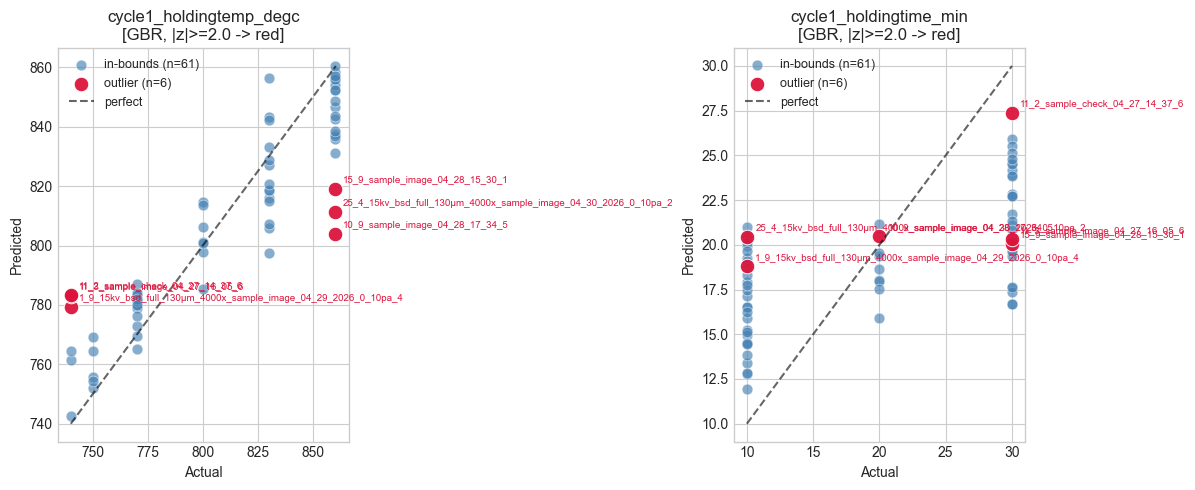


Saved outlier table -> /Users/ayobamibamigboye/capstone/model/runs/debug_lowres/20260504_100001_f151/outlier_test_predictions.csv
Saved annotated plot -> /Users/ayobamibamigboye/capstone/model/runs/debug_lowres/20260504_100001_f151/outlier_test_predictions.png


In [36]:
# ── Outlier test predictions ────────────────────────────────────────────────
# Flag and highlight test rows where the best-of-top-3 model fails badly.
# Uses standardized residuals (z = residual / std). A row is flagged when its
# max |z| across targets exceeds OUTLIER_Z_THRESHOLD.

import pandas as pd
import matplotlib.pyplot as plt

OUTLIER_Z_THRESHOLD = 2.0

# Per-target standardized residuals on the test set.
residuals_per_target = Y_test - Y_pred              # (n_test, n_targets)
target_std = residuals_per_target.std(axis=0)       # std per target (population)
# Guard against a degenerate target with zero residual std (would NaN-out z).
target_std_safe = np.where(target_std > 0, target_std, 1.0)
z_per_target = residuals_per_target / target_std_safe
abs_z_max  = np.abs(z_per_target).max(axis=1)
is_outlier = abs_z_max >= OUTLIER_Z_THRESHOLD

# ── Build the row-level frame ───────────────────────────────────────────────
_id_cols = [c for c in ["id", "alloy", "article_url"] if c in df_test_c1.columns]

rows = []
for i in range(len(Y_test)):
    row = {col: df_test_c1.iloc[i][col] for col in _id_cols}
    for t_idx, col in enumerate(target_columns):
        short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
        row[f"{short}_actual"] = float(Y_test[i, t_idx])
        row[f"{short}_pred"]   = float(Y_pred[i, t_idx])
        row[f"{short}_resid"]  = float(residuals_per_target[i, t_idx])
        row[f"{short}_z"]      = float(z_per_target[i, t_idx])
    row["abs_z_max"]  = float(abs_z_max[i])
    row["is_outlier"] = bool(is_outlier[i])
    rows.append(row)

df_outliers = pd.DataFrame(rows).sort_values("abs_z_max", ascending=False).reset_index(drop=True)
n_flagged = int(df_outliers["is_outlier"].sum())

print(f"Outlier test predictions  (model={_best_name}, threshold |z| >= {OUTLIER_Z_THRESHOLD})")
print(f"  flagged: {n_flagged}/{len(df_outliers)}  "
      f"({100 * n_flagged / max(len(df_outliers), 1):.1f}% of test set)")
print(f"  per-target std: " + ", ".join(f"{c}={s:.2f}" for c, s in zip(target_columns, target_std)))

# ── Highlight flagged IDs ───────────────────────────────────────────────────
# Print one line per flagged test row showing which target(s) tripped and by
# how many sigmas. This is the canonical "which IDs are outliers" answer.
flagged = df_outliers[df_outliers["is_outlier"]].copy()
print()
print("=" * 90)
print(f"FLAGGED OUTLIER IDS  ({n_flagged} rows, sorted by max |z|)")
print("=" * 90)

if n_flagged == 0:
    print("  (none — every test row is within the |z| threshold)")
else:
    for _, r in flagged.iterrows():
        # Build a per-target reason string showing which targets are over the threshold.
        reasons = []
        for col in target_columns:
            short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
            z = r[f"{short}_z"]
            mark = " *" if abs(z) >= OUTLIER_Z_THRESHOLD else "  "
            reasons.append(f"{short}: z={z:+5.2f}{mark}  "
                           f"actual={r[f'{short}_actual']:7.2f}  "
                           f"pred={r[f'{short}_pred']:7.2f}  "
                           f"err={r[f'{short}_resid']:+7.2f}")
        _id    = r.get("id", "")
        _alloy = r.get("alloy", "")
        print(f"  ID={_id!s:<35s}  alloy={_alloy!s:<22s}  abs_z_max={r['abs_z_max']:.2f}")
        for line in reasons:
            print(f"      {line}")
    print()
    print("  Stars (*) mark targets whose own |z| crosses the threshold.")

# Bare flagged-id list at the end so the IDs can be copied verbatim.
flagged_ids = flagged["id"].tolist() if "id" in flagged.columns else []
print()
print(f"Outlier IDs (n={len(flagged_ids)}): {flagged_ids}")

# ── Per-target rankings (still useful for context) ──────────────────────────
for t_idx, col in enumerate(target_columns):
    short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
    z_col = f"{short}_z"
    print(f"\nTop 5 worst predictions for {col}  (sorted by |{z_col}|):")
    print("-" * 90)
    _per_target = df_outliers.assign(_abs=df_outliers[z_col].abs()).sort_values(
        "_abs", ascending=False).drop(columns="_abs")
    _per_cols = _id_cols + [f"{short}_actual", f"{short}_pred",
                            f"{short}_resid", z_col, "is_outlier"]
    print(_per_target[_per_cols].head(5).to_string(index=False,
            float_format=lambda x: f"{x:7.2f}"))

# ── Predicted vs actual with outliers highlighted ───────────────────────────
# One subplot per target. Non-outliers in steel blue, outliers in red, each
# outlier annotated with its ID so the eye-catching dots map back to rows.
n_targets = len(target_columns)
fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5), squeeze=False)
axes = axes[0]
for t_idx, col in enumerate(target_columns):
    ax = axes[t_idx]
    short = col.replace("cycle1_", "c1_").replace("_degc", "").replace("_min", "")
    y_true = Y_test[:, t_idx]
    y_pred = Y_pred[:, t_idx]
    mask   = is_outlier  # row-level outlier flag (same for both targets)

    ax.scatter(y_true[~mask], y_pred[~mask], alpha=0.65, color="steelblue",
               edgecolors="white", linewidth=0.5, s=60, label=f"in-bounds (n={(~mask).sum()})")
    ax.scatter(y_true[mask],  y_pred[mask],  alpha=0.95, color="crimson",
               edgecolors="white", linewidth=0.7, s=110, label=f"outlier (n={mask.sum()})")

    # Annotate flagged points with their IDs.
    if "id" in df_test_c1.columns:
        for i in np.where(mask)[0]:
            ax.annotate(str(df_test_c1.iloc[i]["id"]),
                        (y_true[i], y_pred[i]),
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=7, color="crimson")

    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5, alpha=0.6, label="perfect")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"{col}\n[{_best_name}, |z|>={OUTLIER_Z_THRESHOLD} -> red]")
    ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig(str(_run_dir / "outlier_test_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Persist full table to the run directory ────────────────────────────────
_outlier_path = _run_dir / "outlier_test_predictions.csv"
df_outliers.to_csv(_outlier_path, index=False)
print(f"\nSaved outlier table -> {_outlier_path}")
print(f"Saved annotated plot -> {_run_dir / 'outlier_test_predictions.png'}")


In [37]:
# ── Final summary — top 3 comparison ─────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

n_samples = len(df_c1)
print("=" * 60)
print("CYCLE 1 MODEL SUMMARY — TOP 3 REGRESSORS")
print("=" * 60)
print(f"Dataset : {n_samples} samples")
print(f"Targets : {target_columns} ({len(target_columns)} outputs)")
print(f"Tabular : {X_tab_train.shape[1]} features (chemical composition)")
image_dim = X_img_train.shape[1] if X_img_train is not None else 0
print(f"Image   : {image_dim} features ({'from cache' if image_dim > 0 else 'not available'})")
print(f"Total   : {X_te.shape[1]} features")
print()

print(f"{'Model':<14} {'R²':>8} {'MAE':>10} {'RMSE':>10}  per-target R²")
print("-" * 65)
for _n in _top3_names:
    _yp = top3_preds[_n]
    m   = top3_metrics[_n]
    _pt = "  ".join(f"{r2_score(Y_test[:, i], _yp[:, i]):.3f}" for i in range(len(target_columns)))
    _marker = "  ◀ best" if _n == _best_name else ""
    print(f"  {_n:<12} {m['R2']:8.4f} {m['MAE']:10.4f} {m['RMSE']:10.4f}  [{_pt}]{_marker}")

print()
print(f"Best model : {_best_name}")
print(f"Test R²    : {top3_metrics[_best_name]['R2']:.4f}")
print(f"Test MAE   : {top3_metrics[_best_name]['MAE']:.4f}")
print("=" * 60)


CYCLE 1 MODEL SUMMARY — TOP 3 REGRESSORS
Dataset : 444 samples
Targets : ['cycle1_holdingtemp_degc', 'cycle1_holdingtime_min'] (2 outputs)
Tabular : 118 features (chemical composition)
Image   : 768 features (from cache)
Total   : 886 features

Model                R²        MAE       RMSE  per-target R²
-----------------------------------------------------------------
  XGB            0.4756    11.8474    15.6183  [0.783  0.168]
  GBR            0.5778    10.6161    14.5113  [0.810  0.346]  ◀ best

Best model : GBR
Test R²    : 0.5778
Test MAE   : 10.6161


## 8. Log Run Metrics

Records all key metrics from this run to `runs/metrics_log.csv` for longitudinal tracking.
Call `m.add_tag()` before `log_run(m)` to annotate what changed (e.g. `smogn=True`, `backbone=resnet50`).

In [38]:
# ── Metrics logging ──────────────────────────────────────────────────────────
# Appends one row to runs/metrics_log.csv every time this cell executes.
# Edit add_tag() to annotate what changed in this run.

from src.metrics_logger import RunMetrics, log_run, load_log
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Cycle 1 metrics ───────────────────────────────────────────────────────────
best = trainer.best_model_name
c1_r2_avg   = test_results[best]["R2"]
c1_mae_avg  = test_results[best]["MAE"]
c1_rmse_avg = test_results[best]["RMSE"]

per_target = {}
for i, col in enumerate(target_columns):
    short = "holdingtemp" if "temp" in col else "holdingtime"
    r2   = r2_score(Y_test[:, i], Y_pred[:, i])
    mae  = mean_absolute_error(Y_test[:, i], Y_pred[:, i])
    rmse = float(np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i])))
    per_target[short] = (r2, mae, rmse)

# ── CV R² (from cv_scores dict) ────────────────────────────────────────────────
try:
    _cv_arr  = cv_scores.get("RF", cv_scores.get("ABR"))
    _cv_mean = float(_cv_arr.mean())
    _cv_std  = float(_cv_arr.std())
except Exception:
    _cv_mean = _cv_std = None

# ── Bayesian-tuned R² ────────────────────────────────────────────────────────
try:
    _bayes_tag  = f"bayes_best={best_tuned_name},r2={best_tuned_r2:.4f}"
    _bayes_delta = bayes_eval[best_tuned_name]["delta"]
    _bayes_tag  += f",delta={_bayes_delta:+.4f}"
    # Override CV R² with the tuned estimate if it beats the untuned
    if best_tuned_r2 > (_cv_mean or 0):
        _cv_mean = best_tuned_r2
        _cv_std  = bayes_eval[best_tuned_name]["tuned_std"]
except Exception:
    _bayes_tag = None

# ── Cycle 1+2 metrics (optional) ─────────────────────────────────────────────
try:
    best_ext      = trainer_ext.best_model_name
    c1c2_r2_avg   = test_results_ext[best_ext]["R2"]
    c1c2_mae_avg  = test_results_ext[best_ext]["MAE"]
    c1c2_rmse_avg = test_results_ext[best_ext]["RMSE"]
except Exception:
    best_ext = c1c2_r2_avg = c1c2_mae_avg = c1c2_rmse_avg = None

# ── Backbone used ─────────────────────────────────────────────────────────────
try:
    _backbone = BACKBONE
except NameError:
    _backbone = "none"

# ── Feature stream dimensions ─────────────────────────────────────────────────
_n_image   = X_img_train.shape[1]   if X_img_train   is not None else None
_n_morph   = X_morph_train.shape[1] if X_morph_train is not None else None
_n_tabular = X_tab_train.shape[1]   if X_tab_train   is not None else None
try:
    _morph_matched = int((~np.isnan(X_morph_all).any(axis=1)).sum())
except Exception:
    _morph_matched = None

# ── Build RunMetrics ──────────────────────────────────────────────────────────
m = RunMetrics(notebook="microstructure_debug_lowres")
m.set_dataset(
    n_samples=len(df_c1), n_features=X_train.shape[1], backbone=_backbone,
    n_image_features=_n_image, n_morph_features=_n_morph,
    n_tabular_features=_n_tabular, morph_rows_matched=_morph_matched,
)
m.set_c1(
    best_model=best,
    test_r2_avg=c1_r2_avg, test_mae_avg=c1_mae_avg, test_rmse_avg=c1_rmse_avg,
    per_target=per_target, cv_r2_mean=_cv_mean, cv_r2_std=_cv_std,
)
if best_ext is not None:
    m.set_c1c2(best_model=best_ext,
               test_r2_avg=c1c2_r2_avg, test_mae_avg=c1c2_mae_avg, test_rmse_avg=c1c2_rmse_avg)

# ── Auto-tag from this run ────────────────────────────────────────────────────
_auto_tags = []
if _bayes_tag:
    _auto_tags.append(_bayes_tag)
if _backbone != "none":
    _auto_tags.append(f"backbone={_backbone}")
if X_morph_train is not None:
    _auto_tags.append("morph=True")
m.add_tag(*_auto_tags)
# Add your own annotations here, e.g.:  m.add_tag("smogn=True", "pruned=True")

# ── Write + display ───────────────────────────────────────────────────────────
log_path = log_run(m)
m.print_summary()
print(f"\nAppended to: {log_path}")

# Show full history when more than one run exists
df_log = load_log()
if len(df_log) > 1:
    print(f"\nAll {len(df_log)} runs logged:")
    view_cols = ["timestamp", "git_commit", "backbone",
                 "c1_best_model", "c1_test_r2_avg",
                 "c1_holdingtemp_r2", "c1_holdingtime_r2",
                 "c1_cv_r2_mean", "c1c2_test_r2_avg", "tags"]
    print(df_log[[c for c in view_cols if c in df_log.columns]].to_string(index=False))
# ── RunStore: write manifest + history + update visualisation ─────────────────
_run_row = m.to_row()
_store.write_manifest({
    'backbone':           _backbone,
    'n_samples':          len(df_c1),
    'n_features':         int(X_train.shape[1]),
    'n_image_features':   _n_image,
    'n_morph_features':   _n_morph,
    'n_tabular_features': _n_tabular,
    'c1_best_model':      best,
    'c1_test_r2_avg':     c1_r2_avg,
    'c1_holdingtemp_r2':  per_target.get('holdingtemp', (None,))[0],
    'c1_holdingtime_r2':  per_target.get('holdingtime', (None,))[0],
    'c1_cv_r2_mean':      _cv_mean,
    'c1_cv_r2_std':       _cv_std,
    'c1c2_best_model':    best_ext,
    'c1c2_test_r2_avg':   c1c2_r2_avg,
    'tags':               '; '.join(_auto_tags),
})

_store.append_history({
    'backbone':           _backbone,
    'n_samples':          len(df_c1),
    'n_features':         int(X_train.shape[1]),
    'best_model':         best,
    'c1_test_r2_avg':     c1_r2_avg,
    'c1_holdingtemp_r2':  per_target.get('holdingtemp', (None,))[0],
    'c1_holdingtime_r2':  per_target.get('holdingtime', (None,))[0],
    'c1_cv_r2_mean':      _cv_mean,
    'c1_cv_r2_std':       _cv_std,
    'c1c2_test_r2_avg':   c1c2_r2_avg,
    'tags':               '; '.join(_auto_tags),
})

# Copy model comparison artifact if it was saved
try:
    _mc_src = _run_dir / 'model_comparison.png'
    if not _mc_src.exists():
        import glob as _glob
        _candidates = _glob.glob('../runs/*/model_comparison.png')
        # already in run_dir from cell 35 savefig
    pass
except Exception:
    pass

# Regenerate run-family history visualisation
from pathlib import Path as _Path
metrics_viz.plot_history('debug_lowres', save=True, show=False)
print(f'History visualisation -> runs/debug_lowres/metrics_history.png')
print(f'Run artifacts stored  -> {_run_dir}')


RUN LOGGED  [2026-05-04 10:03:22]  commit=d911410
  dataset   : 444 samples, 919 features, backbone=dinov2_vitb14
  streams   : image=768  morph=33 (matched=)  tabular=118
  C1 model  : RF  test R²=0.5342  MAE=11.4469  RMSE=15.1530
             holdingtemp  R²=0.8101  MAE=14.5003  RMSE=19.0937
             holdingtime  R²=0.3456  MAE=6.7320  RMSE=7.5225
             CV R²=0.8266 ± 0.0397
  tags      : bayes_best=KNN,r2=0.8266,delta=+0.0000; backbone=dinov2_vitb14; morph=True

Appended to: /Users/ayobamibamigboye/capstone/model/runs/metrics_log.csv

All 16 runs logged:
          timestamp git_commit      backbone c1_best_model  c1_test_r2_avg  c1_holdingtemp_r2  c1_holdingtime_r2  c1_cv_r2_mean  c1c2_test_r2_avg                                                                       tags
2026-04-14 10:43:05    8273fd7 dinov2_vitb14           GBR          0.7349             0.4872             0.9826         0.5087            0.9336                                                           

## 9. Prediction Tester — Predict Heat Treatment from a Microstructure Image

Pass in a microstructure image and an alloy class; the tester extracts CNN + morph + tabular features in the same order used at training, fits the chosen top-3 model on the full train split, and predicts (HoldingTemp, HoldingTime).

Use `list_alloys()` to see available alloy classes. Chemistry is looked up by alloy from the training dataset (median over rows).


In [39]:
# ── Prediction tester ─────────────────────────────────────────────────────────
# Predict (HoldingTemp, HoldingTime) for a single microstructure image,
# given the alloy class. Chemistry is determined by alloy in this dataset.

import os, copy
import numpy as np
import pandas as pd
from src.extraction import MorphologicalExtractor
from src.extraction.extractor import ExtractionConfig, FeatureExtractor


def list_alloys():
    """Return sorted list of alloy classes available in the training dataset."""
    return sorted(df_c1['alloy'].dropna().unique().tolist())


def _chemistry_for_alloy(alloy):
    """Median chemistry vector for *alloy* across feature_columns."""
    rows = df_c1[df_c1['alloy'] == alloy]
    if rows.empty:
        raise ValueError(
            f'Unknown alloy={alloy!r}. Available alloys:\n  '
            + '\n  '.join(list_alloys())
        )
    medians = rows[feature_columns].median(numeric_only=True)
    return {c: medians.get(c, np.nan) for c in feature_columns}


def predict_from_image(image_path, alloy, model_name=None, verbose=True):
    """
    Predict heat treatment from a microstructure image + alloy class.

    Parameters
    ----------
    image_path : str
        Path to a microstructure image (jpg/png/tif).
    alloy : str
        Alloy class name. Use list_alloys() to see options.
    model_name : str, optional
        One of the top-3 model names. Defaults to the best (`_best_name`).
    verbose : bool
        Print step-by-step extraction details.
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f'Image not found: {image_path}')

    name = model_name or _best_name
    if name not in cv_models:
        raise ValueError(f'Unknown model {name!r}. Available: {list(cv_models)}')

    chem_row = _chemistry_for_alloy(alloy)
    chem_df  = pd.DataFrame([chem_row])

    if verbose:
        n_rows_alloy = (df_c1['alloy'] == alloy).sum()
        print(f'Predicting for: {os.path.basename(image_path)}')
        print(f'  Alloy: {alloy}  (chemistry from {n_rows_alloy} dataset row(s))')
        print(f'  Model: {name}')

    X_tab_one = preprocessor.transform(chem_df.copy())
    if verbose:
        print(f'  Tabular features: {X_tab_one.shape}')

    parts = []
    img_dim = morph_dim = 0
    if X_img_train is not None:
        cfg = ExtractionConfig(backbones=[BACKBONE], img_size=224,
                               batch_size=1, num_workers=0)
        extractor = FeatureExtractor(cfg)
        X_img_one, _ = extractor.extract_features([image_path])
        parts.append(X_img_one.astype(np.float64))
        img_dim = X_img_one.shape[1]
        if verbose:
            print(f'  Image features ({BACKBONE}): {X_img_one.shape}')

    if X_morph_train is not None:
        morph = MorphologicalExtractor()
        X_morph_one = morph.extract_single(image_path).reshape(1, -1)
        parts.append(X_morph_one.astype(np.float64))
        morph_dim = X_morph_one.shape[1]
        if verbose:
            print(f'  Morph features: {X_morph_one.shape}')

    parts.append(X_tab_one.astype(np.float64))
    X_one = np.concatenate(parts, axis=1)

    if np.isnan(X_one).any():
        train_means = np.nanmean(X_train, axis=0)
        nan_mask = np.isnan(X_one)
        X_one[nan_mask] = np.take(train_means, np.where(nan_mask)[1])

    if verbose:
        print(f'  Combined: {X_one.shape}  '
              f'[img={img_dim}, morph={morph_dim}, tab={X_tab_one.shape[1]}]')

    model = copy.deepcopy(cv_models[name])
    model.fit(X_train, Y_train)
    Y_pred_one = model.predict(X_one)
    if Y_pred_one.ndim == 1:
        Y_pred_one = Y_pred_one.reshape(1, -1)

    predictions = {col: float(Y_pred_one[0, i]) for i, col in enumerate(target_columns)}

    if verbose:
        print()
        print('Predicted heat treatment:')
        for col, val in predictions.items():
            unit = '°C' if 'temp' in col.lower() else 'min'
            print(f'  {col:<35} = {val:.1f} {unit}')

    return {
        'predictions':  predictions,
        'model':        name,
        'image':        image_path,
        'alloy':        alloy,
        'feature_dims': {'image': img_dim, 'morph': morph_dim,
                         'tabular': X_tab_one.shape[1]},
    }


# ── Example: predict for the first sample in the test set ────────────────
example_row   = df_c1.iloc[idx_test[0]]
example_id    = example_row['id']
example_alloy = example_row['alloy']
example_path  = None
for ext in ('.jpg', '.png', '.jpeg', '.tif', '.tiff'):
    candidate = os.path.join(TEMP_DIR, f'{example_id}{ext}')
    if os.path.exists(candidate):
        example_path = candidate
        break
    candidate = os.path.join(TEMP_DIR, f'{example_id}_F_0{ext}')
    if os.path.exists(candidate):
        example_path = candidate
        break

print(f'Available alloys ({len(list_alloys())}):')
for a in list_alloys():
    print(f'  - {a}')
print()

if example_path is None:
    print(f'No image found in {TEMP_DIR} for id={example_id}.')
    print('To use the predictor, call:')
    print("  predict_from_image('/path/to/microstructure.jpg', alloy='<alloy name>')")
else:
    result = predict_from_image(example_path, alloy=example_alloy)
    print()
    actual = Y_c1[idx_test[0]]
    print('Actual heat treatment (from dataset):')
    for col, val in zip(target_columns, actual):
        unit = '°C' if 'temp' in col.lower() else 'min'
        print(f'  {col:<35} = {val:.1f} {unit}')
    print()
    print('Absolute error:')
    for i, col in enumerate(target_columns):
        e = abs(result['predictions'][col] - actual[i])
        unit = '°C' if 'temp' in col.lower() else 'min'
        print(f'  {col:<35} = {e:.1f} {unit}')


Available alloys (5):
  - DP1180 GA
  - DP590 GA
  - DP600 GI
  - DP780 GA
  - DP980 GA

Predicting for: 3_5_sample_image_04_27_19_42_1_F_0.jpg
  Alloy: DP980 GA  (chemistry from 89 dataset row(s))
  Model: GBR
  Tabular features: (1, 118)
Initializing feature extractor on mps...


Using cache found in /Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main
/Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  Loaded dinov2_vitb14: 768 features
  Total feature dimension: 768


Extracting features: 100%|██████████| 1/1 [00:01<00:00,  1.68s/it]


  Image features (dinov2_vitb14): (1, 768)
  Morph features: (1, 33)
  Combined: (1, 919)  [img=768, morph=33, tab=118]

Predicted heat treatment:
  cycle1_holdingtemp_degc             = 804.2 °C
  cycle1_holdingtime_min              = 17.9 min

Actual heat treatment (from dataset):
  cycle1_holdingtemp_degc             = 800.0 °C
  cycle1_holdingtime_min              = 10.0 min

Absolute error:
  cycle1_holdingtemp_degc             = 4.2 °C
  cycle1_holdingtime_min              = 7.9 min


In [42]:
predict_from_image("/Users/ayobamibamigboye/capstone/model/data/temp_images/3_4_sample_image_04_27_19_40_6_F_7.jpg", "DP780 GA")

print("Actual: 800	10")


Predicting for: 3_4_sample_image_04_27_19_40_6_F_7.jpg
  Alloy: DP780 GA  (chemistry from 84 dataset row(s))
  Model: GBR
  Tabular features: (1, 118)
Initializing feature extractor on mps...


Using cache found in /Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main


  Loaded dinov2_vitb14: 768 features
  Total feature dimension: 768


Extracting features: 100%|██████████| 1/1 [00:00<00:00,  6.33it/s]

  Image features (dinov2_vitb14): (1, 768)


  Morph features: (1, 33)
  Combined: (1, 919)  [img=768, morph=33, tab=118]

Predicted heat treatment:
  cycle1_holdingtemp_degc             = 799.5 °C
  cycle1_holdingtime_min              = 11.4 min
Actual: 800	10


In [43]:
predict_from_image("/Users/ayobamibamigboye/capstone/model/data/temp_images/3_3_sample_image_04_27_19_23_1_F_6.jpg", "DP1180 GA")

print("Actual: 800	10")

Predicting for: 3_3_sample_image_04_27_19_23_1_F_6.jpg
  Alloy: DP1180 GA  (chemistry from 88 dataset row(s))
  Model: GBR
  Tabular features: (1, 118)
Initializing feature extractor on mps...


Using cache found in /Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main


  Loaded dinov2_vitb14: 768 features
  Total feature dimension: 768


Extracting features: 100%|██████████| 1/1 [00:00<00:00,  6.03it/s]

  Image features (dinov2_vitb14): (1, 768)


  Morph features: (1, 33)
  Combined: (1, 919)  [img=768, morph=33, tab=118]

Predicted heat treatment:
  cycle1_holdingtemp_degc             = 789.4 °C
  cycle1_holdingtime_min              = 14.5 min
Actual: 800	10


In [ ]:
predict_from_image("/Users/ayobamibamigboye/capstone/model/data/temp_images/3_3_sample_image_04_27_19_23_1_F_6.jpg", "DP980 GA")

print("Actual: 800	10")

Predicting for: 3_3_sample_image_04_27_19_23_1_F_6.jpg
  Alloy: DP1180 GA  (chemistry from 88 dataset row(s))
  Model: GBR
  Tabular features: (1, 118)
Initializing feature extractor on mps...


Using cache found in /Users/ayobamibamigboye/.cache/torch/hub/facebookresearch_dinov2_main


  Loaded dinov2_vitb14: 768 features
  Total feature dimension: 768


Extracting features: 100%|██████████| 1/1 [00:00<00:00,  5.41it/s]

  Image features (dinov2_vitb14): (1, 768)


  Morph features: (1, 33)
  Combined: (1, 919)  [img=768, morph=33, tab=118]


KeyboardInterrupt: 